# The profitability of pairs trading strategies using copula methods

**Panagiotis Housos · ph2606**  
NYU · Statistical Arbitrage · Fall 2026

This is a worked, reproducible study of **AAPL–GOOG, IBM–SPY and DIA–SPY**.
The main method reproduces the mixed-copula framework of Sabino da Silva,
Ziegelmann and Caldeira, *Mixed Copula Pairs Trading Strategy on the S&P 500*
(supplied working paper; hereafter paper 1). Profit measurement follows
the fixed-entry long/short and marked-to-market conventions in Rad, Low
and Faff (2016), *The profitability of pairs trading strategies: distance,
cointegration and copula methods* (paper 2).

Both supplied papers were read. Detailed page-specific notes are in
`references/paper1_notes.md` and `references/paper2_notes.md`. The new
experiment uses 2006–2025 trading observations, 12-month formation and
nonoverlapping six-month trading windows. It is a **methodological
reproduction on the three assigned pairs**, not a reconstruction of the
papers' Bloomberg/CRSP universes or published coefficients. ETFs and
today's nominated pairs also differ from those historical universes.

The primary published-style calculation is an **uncapped fixed-stake
P&L diagnostic**. It can exhaust initial capital and is then not a
feasible funded trading history. A supplementary account scales each
new trade to surviving equity and reports conventional compounded wealth.

This notebook verifies data and fitted caches, reruns the trading and
reporting calculations, audits a trade by hand, and displays the results.
Model refitting is a separate, slower command. No live orders are placed.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

candidates = [Path.cwd(), Path.cwd() / 'Copula-Pairs-Trading', Path.cwd().parent]
ROOT = next((p.resolve() for p in candidates if (p / 'src' / 'copulas.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Launch this notebook from the Copula-Pairs-Trading project folder.')
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('Project:', ROOT.name)
print('Python:', sys.version.split()[0], '| NumPy:', np.__version__, '| pandas:', pd.__version__)

Project: Copula-Pairs-Trading
Python: 3.12.5 | NumPy: 1.26.4 | pandas: 2.2.2


## 1. Data and causal design

Yahoo adjusted closes supply total-return price indices. We use decimal
log returns for the marginal/copula signal models, and price changes of
the adjusted indices for cash P&L. These indices represent synthetic
total-return units; dividends are **not** credited a second time.
Missing observations are not filled. The data manifest records the
request, provider, timestamps, row counts and SHA-256 hashes.

Each fit uses only the preceding 12 calendar months. Copula parameters,
ARMA–GARCH coefficients and the residual empirical CDF remain frozen
through the following six-month trading period. The GARCH state updates
recursively as returns arrive. A close's signal executes at the **next
close**; established quantities earn only subsequent price changes.
This lag is a disclosed conservative execution choice.

In [2]:
from scripts.download_data import verify_data
from scripts.fit_models import load_prices, fingerprint, WINDOWS, PAIRS

manifest = verify_data()  # Stops if an input hash or requested period differs.
prices = load_prices()
coverage = pd.DataFrame(manifest['files']).T
display(coverage[['rows', 'first_date', 'last_date', 'dividend_events', 'split_events']])
print('Provider:', manifest['provider'])
print('Retrieved UTC:', manifest['retrieved_utc'])
print('OOS windows:', len(WINDOWS), '| Assigned pairs:', PAIRS)
print('Current model/input fingerprint:', fingerprint())

,rows,first_date,last_date,dividend_events,split_events
AAPL,5305,2004-12-01,2025-12-31,54,3
GOOG,5305,2004-12-01,2025-12-31,7,3
IBM,5305,2004-12-01,2025-12-31,84,1
DIA,5305,2004-12-01,2025-12-31,252,0
SPY,5305,2004-12-01,2025-12-31,85,0


Provider: Yahoo Finance via yfinance
Retrieved UTC: 2026-09-26T16:02:34.362711+00:00
OOS windows: 40 | Assigned pairs: [('AAPL', 'GOOG'), ('IBM', 'SPY'), ('DIA', 'SPY')]
Current model/input fingerprint: a259e22e5ea48277d4fdff2ca9b3b87fef9d5ea3b6021ce525036380c6ae4d01


## 2. Reproduce the experiment

Paper 1 models marginal returns using ARMA(p,q)–GARCH(1,1), with
p,q in {0,1}. This implementation fits Gaussian quasi-maximum likelihood
and uses AIC to select those four marginal orders; the paper leaves
these two choices unspecified. Standardized formation residuals become
empirical uniforms, $u_i=\operatorname{rank}(z_i)/(n+1)$, with a frozen
formation CDF and boundary clipping in trading.

The dependence candidates are Gaussian, Student t, Clayton, Frank,
Gumbel, CFG (Clayton–Frank–Gumbel), and CtG (Clayton–t–Gumbel). A mixture
has nonnegative weights summing to one. Its likelihood is
$\sum_t\log[\sum_j\pi_j c_j(u_t,v_t)]$.
**Selected** uses maximum formation log likelihood, as in paper 1.
**Best-single** restricts this to the five single copulas; **BIC** adds a
parameter penalty. Every single family and both mixtures are also
traded separately for comparison. Better in-sample mixture likelihood
is partly mechanical because mixtures include their component limits.

The following cell recomputes signals, all ledgers and result tables from
the verified fitted caches. It does not optimize choices on trading P&L.
To rebuild the expensive fits after installing `requirements.txt`, run
`python scripts/fit_models.py --workers 4` first. Original vendor CSVs
must be present or retrieved with `python scripts/download_data.py`.

In [3]:
from scripts.run_analysis import run, load_cache

# Full model refit, if needed, from a terminal in this project:
# python scripts/fit_models.py --workers 4
caches = load_cache()  # Verifies every cache against input/model hashes.
print('Verified fitted windows:', len(caches))
run()

Verified fitted windows: 40


Analyzed 2006-01-01


Analyzed 2006-07-01


Analyzed 2007-01-01


Analyzed 2007-07-01


...

Analyzed 2024-01-01


Analyzed 2024-07-01


Analyzed 2025-01-01


Analyzed 2025-07-01


Reinvested account: all checked daily equity values remain positive.
       method  annual_mean_pct  sharpe  max_drawdown_pct  trades
     Selected          -4.9491 -0.4969         -102.8583     537
  Best-single          -5.6406 -0.5832         -111.7250     521
          BIC          -5.7030 -0.5902         -113.0531     510
     Gaussian          -5.4265 -0.5571         -107.8214     492
    Student-t          -5.3316 -0.5431         -105.9189     510
      Clayton          -5.3304 -0.5593         -106.1897     437
        Frank          -6.0913 -0.6382         -123.5454     501
       Gumbel          -4.1482 -0.4443          -84.7004     506
          CFG          -5.0421 -0.5071         -105.4212     552
          CtG          -4.9661 -0.4982         -106.2748     536
     Distance          -1.6046 -0.2767          -40.4753      69
Cointegration           0.2715  0.1525           -6.3826       9
PnL reconciliation maximum absolute error: 5.820766091346741e-11


## 3. Full strategy comparison

Let $K=100{,}000$ be the fixed initial **long-side** capital per pair.
Equal-dollar strategies open $K$ long and $K$ short, so gross exposure
starts at $2K$, while the paper-style return denominator is $K$.
Quantities remain fixed until exit. Reported daily contributions are
$\Delta\mathrm{PnL}_t/K$, and cumulative equity is
$K+\sum_t\Delta\mathrm{PnL}_t$; these contributions are added rather
than compounded as if each trade reinvested all account wealth.

All baseline methods pay 5 bps per dollar per leg fill. There is no
baseline stock-borrow fee or cash interest. The portfolio averages three
equal committed slots, including idle ones. The SPY sleeves are kept
separately and trading costs are not netted across pairs, a difference
from paper 1's restriction on simultaneous positions in the same stock.

Annual mean and volatility use 252 observations per year. Sharpe uses
fixed-capital P&L contributions and a zero financing/risk-free convention.
The primary drawdown is an **algebraic drawdown of uncapped P&L plus
initial capital**. Losses can exceed 100% because the calculation
continues to assume a fixed stake after funding has been exhausted.
Such paths are not feasible funded wealth or ordinary investment returns.
Distance uses paper 2's rebasing rule. Cointegration admits only pairs
passing the formation Engle–Granger 5% screen; rejected slots stay in cash.

In [4]:
performance = pd.read_csv(RESULTS / 'performance.csv')
fits = pd.read_csv(RESULTS / 'copula_fits.csv')
margins = pd.read_csv(RESULTS / 'marginal_fits.csv')
monthly = pd.read_csv(RESULTS / 'monthly_returns.csv', parse_dates=['Date'])
trades = pd.read_csv(RESULTS / 'trades.csv', parse_dates=['entry_date', 'exit_date'])
daily = pd.read_csv(RESULTS / 'daily_ledger.csv', parse_dates=['Date'])
audit = json.loads((RESULTS / 'audit.json').read_text())
columns = ['method', 'pair', 'basis', 'cumulative_pnl_pct', 'annual_mean_pct',
           'annual_vol_pct', 'sharpe', 'max_drawdown_pct', 'trades']
for basis in ['net', 'gross']:
    display(Markdown(f'### {basis.title()} uncapped fixed-stake P&L / initial long-side capital'))
    display(performance.loc[performance.basis.eq(basis), columns]
            .rename(columns={'max_drawdown_pct': 'algebraic_drawdown_pct'})
            .reset_index(drop=True))

### Net uncapped fixed-stake P&L / initial long-side capital

,method,pair,basis,cumulative_pnl_pct,annual_mean_pct,annual_vol_pct,sharpe,algebraic_drawdown_pct,trades
0,Selected,AAPL-GOOG,net,-192.9307,-9.6638,24.5791,-0.3932,-172.9191,170
1,Selected,IBM-SPY,net,-47.8805,-2.3983,15.9202,-0.1506,-69.8456,175
2,Selected,DIA-SPY,net,-55.6066,-2.7853,4.6754,-0.5957,-64.5508,192
3,Selected,Portfolio,net,-98.8059,-4.9491,9.9605,-0.4969,-102.8583,537
4,Best-single,AAPL-GOOG,net,-212.4633,-10.6422,23.7111,-0.4488,-191.9620,159
5,Best-single,IBM-SPY,net,-65.9358,-3.3027,15.6974,-0.2104,-84.4768,174
6,Best-single,DIA-SPY,net,-59.4349,-2.9771,4.6618,-0.6386,-65.3825,188
7,Best-single,Portfolio,net,-112.6113,-5.6406,9.6721,-0.5832,-111.7250,521
8,BIC,AAPL-GOOG,net,-214.0337,-10.7208,23.7276,-0.4518,-190.8022,153
9,BIC,IBM-SPY,net,-68.4576,-3.4290,15.6444,-0.2192,-86.4289,171


### Gross uncapped fixed-stake P&L / initial long-side capital

,method,pair,basis,cumulative_pnl_pct,annual_mean_pct,annual_vol_pct,sharpe,algebraic_drawdown_pct,trades
0,Selected,AAPL-GOOG,gross,-158.5618,-7.9423,24.5792,-0.3231,-145.6071,170
1,Selected,IBM-SPY,gross,-12.7480,-0.6385,15.9224,-0.0401,-48.8694,175
2,Selected,DIA-SPY,gross,-17.0337,-0.8532,4.6488,-0.1835,-32.5357,192
3,Selected,Portfolio,gross,-62.7812,-3.1447,9.9581,-0.3158,-72.3485,537
4,Best-single,AAPL-GOOG,gross,-180.3312,-9.0327,23.7137,-0.3809,-162.3708,159
5,Best-single,IBM-SPY,gross,-31.0082,-1.5532,15.6905,-0.0990,-60.0403,174
6,Best-single,DIA-SPY,gross,-21.6927,-1.0866,4.6382,-0.2343,-32.3034,188
7,Best-single,Portfolio,gross,-77.6774,-3.8908,9.6722,-0.4023,-79.9371,521
8,BIC,AAPL-GOOG,gross,-183.1344,-9.1731,23.7296,-0.3866,-163.1929,153
9,BIC,IBM-SPY,gross,-34.1184,-1.7090,15.6379,-0.1093,-61.8441,171


### Funding diagnosis and an equity-funded comparison

Continuing a constant dollar stake after the original capital is gone
would require new external funding. The dates below identify this
concrete failure in the primary uncapped calculation. Its subsequent
P&L is a shadow calculation, not the value of a solvent trading account.

The supplementary account starts each pair with equal capital and
sizes **each new entry** to that sleeve's then-current surviving equity.
Quantities remain fixed within a trade and all published signals, costs
and expiry rules stay unchanged. The three sleeves are not rebalanced
into each other. Daily percentage returns use preceding account equity,
so their compounded total and CAGR are meaningful for this comparison.
Financing, broker margin requirements and intra-trade leverage limits
remain idealized. Positivity of a simulated balance alone does not
establish compliance with real margin rules.

In [5]:
capital_diagnostics = pd.DataFrame(json.loads((RESULTS / 'capital_diagnostics.json').read_text()))
funded = pd.read_csv(RESULTS / 'reinvested_performance.csv')
funded_daily = pd.read_csv(RESULTS / 'reinvested_daily.csv', parse_dates=['Date'])
exhausted = capital_diagnostics.loc[capital_diagnostics.first_nonpositive_equity.notna()]
display(Markdown('**Funding failure in the uncapped fixed-stake calculation:**'))
display(exhausted)
assert funded_daily.equity_per_initial_dollar.gt(0).all()
display(Markdown('**Supplementary equity-at-entry account — net, funded-return conventions:**'))
display(funded[['method', 'pair', 'cumulative_return_pct', 'cagr_pct', 'sharpe',
                'max_drawdown_pct', 'final_equity_per_initial_dollar']])
selected_capital = capital_diagnostics.loc[capital_diagnostics.method.eq('Selected') &
                                            capital_diagnostics.pair.eq('Portfolio')].iloc[0]
if pd.notna(selected_capital.first_nonpositive_equity):
    display(Markdown(f'**The selected fixed-stake portfolio exhausts its original capital on '
                     f'{selected_capital.first_nonpositive_equity}. Its later shadow P&L '
                     'cannot be interpreted as feasible investment wealth.**'))

**Funding failure in the uncapped fixed-stake calculation:**

,method,pair,first_nonpositive_equity,minimum_equity_per_initial_dollar
0,Selected,AAPL-GOOG,2013-08-13,-0.9708
3,Selected,Portfolio,2024-09-06,-0.0303
4,Best-single,AAPL-GOOG,2013-05-15,-1.1487
7,Best-single,Portfolio,2024-04-01,-0.1261
8,BIC,AAPL-GOOG,2013-07-26,-1.1644
11,BIC,Portfolio,2024-04-01,-0.1386


**Supplementary equity-at-entry account — net, funded-return conventions:**

,method,pair,cumulative_return_pct,cagr_pct,sharpe,max_drawdown_pct,final_equity_per_initial_dollar
0,Selected,AAPL-GOOG,-95.6356,-14.5181,-0.4056,-96.6937,0.0436
1,Selected,IBM-SPY,-49.5414,-3.3682,-0.1238,-66.2751,0.5046
2,Selected,DIA-SPY,-44.0190,-2.8642,-0.5901,-48.8390,0.5598
3,Selected,Portfolio,-63.0654,-4.8666,-0.4667,-66.9049,0.3693
4,Best-single,AAPL-GOOG,-95.1927,-14.1032,-0.4255,-96.1432,0.0481
5,Best-single,IBM-SPY,-57.9544,-4.2470,-0.1833,-72.0361,0.4205
6,Best-single,DIA-SPY,-46.0324,-3.0422,-0.6309,-49.2051,0.5397
7,Best-single,Portfolio,-66.3932,-5.3155,-0.5483,-70.0737,0.3361
8,BIC,AAPL-GOOG,-95.3999,-14.2925,-0.4310,-96.4448,0.0460
9,BIC,IBM-SPY,-59.5344,-4.4305,-0.1967,-72.9114,0.4047


**The selected fixed-stake portfolio exhausts its original capital on 2024-09-06. Its later shadow P&L cannot be interpreted as feasible investment wealth.**

## 4. What was fitted?

Count selections across formation windows rather than treating every
daily probability as a separate model. NLL and BIC can select different
models because mixture flexibility incurs a BIC penalty. These counts
describe fitted dependence, not probabilities of earning a profit.

In [6]:
family_order = ['Gaussian', 'Student-t', 'Clayton', 'Frank', 'Gumbel', 'CFG', 'CtG']
selection_counts = pd.concat({
    'Log likelihood': fits.loc[fits.selected].groupby(['pair', 'family']).size(),
    'BIC': fits.loc[fits.selected_bic].groupby(['pair', 'family']).size(),
}, axis=1).fillna(0).astype(int)
display(selection_counts)
display(margins.groupby(['symbol', 'p', 'q']).size().rename('formation_windows').to_frame())
print('All marginal fits converged:', bool(margins.converged.all()))
print('All copula fits successful:', bool(fits.success.all()))
print('Copula fits:', len(fits), '| Marginal fits:', len(margins))

Log likelihood  BIC
pair      family                        
AAPL-GOOG CFG                    13    0
          CtG                    27    0
DIA-SPY   CtG                    38    0
          Student-t               2   23
IBM-SPY   CFG                    12    0
          CtG                    28    0
AAPL-GOOG Clayton                 0   15
          Frank                   0    6
          Gaussian                0    1
          Gumbel                  0    1
          Student-t               0   17
DIA-SPY   Gaussian                0   17
IBM-SPY   Frank                   0    9
          Gaussian                0    7
          Student-t               0   24

formation_windows
symbol p q                   
AAPL   0 0                 35
         1                  2
       1 0                  1
         1                  2
DIA    0 0                 29
         1                  1
       1 0                  1
         1                  9
GOOG   0 0                 30
         1                  2
       1 0                  3
         1                  5
IBM    0 0                 31
         1                  1
       1 0                  3
         1                  5
SPY    0 0                 21
         1                  4
       1 0                  2
         1                 13

All marginal fits converged: True
All copula fits successful: True
Copula fits: 840 | Marginal fits: 200


## 5. Paper 2's committed and employed capital

For month $m$, each pair's contribution includes both realized and
unrealized marked-to-market P&L. With three nominated slots,
$RCC_m=\sum_i\mathrm{PnL}_{i,m}/(3K)$.
If $n_m$ distinct pairs were held or traded at any point during that
month, $REC_m=\sum_i\mathrm{PnL}_{i,m}/(n_mK)$.
Carry-in positions count even if there is no new entry. A month with no
activity has RCC zero and REC undefined (NaN). REC is an exposure-scaled
summary; it does not imply executable monthly capital reallocation.

Paper 2 launches monthly cohorts and averages six overlapping books.
Here the window design follows paper 1's nonoverlapping half-years;
paper 2 contributes P&L sizing and the monthly denominators.

In [7]:
capital_summary = monthly.groupby('method').agg(
    months=('committed', 'size'), employed_months=('employed', 'count'),
    mean_RCC=('committed', 'mean'), mean_REC_active_months=('employed', 'mean'),
    mean_active_pairs=('active_pairs', 'mean'))
capital_summary['mean_RCC_bps'] = 1e4 * capital_summary.pop('mean_RCC')
capital_summary['mean_REC_active_months_bps'] = 1e4 * capital_summary.pop('mean_REC_active_months')
display(capital_summary)
display(monthly.loc[monthly.method.eq('Selected')].head(12))

,months,employed_months,mean_active_pairs,mean_RCC_bps,mean_REC_active_months_bps
method,,,,,
BIC,240,240,2.7917,-47.4398,-51.1275
Best-single,240,240,2.7917,-46.9214,-51.6523
CFG,240,240,2.8333,-41.9426,-44.6431
Clayton,240,233,2.4750,-44.3408,-49.8083
Cointegration,240,25,0.1208,2.2584,75.2148
CtG,240,240,2.8250,-41.3104,-43.7752
Distance,240,150,1.0000,-13.3475,-39.1307
Frank,240,239,2.7500,-50.6700,-58.2042
Gaussian,240,240,2.7917,-45.1400,-51.0674


,Date,committed,employed,active_pairs,nominated_pairs,method
0,2006-01-31,0.0028,0.0028,3,3,Selected
1,2006-02-28,0.0063,0.0063,3,3,Selected
2,2006-03-31,0.0074,0.0111,2,3,Selected
3,2006-04-30,0.0007,0.0010,2,3,Selected
4,2006-05-31,-0.0063,-0.0095,2,3,Selected
5,2006-06-30,0.0126,0.0189,2,3,Selected
6,2006-07-31,-0.0427,-0.0427,3,3,Selected
7,2006-08-31,-0.0169,-0.0169,3,3,Selected
8,2006-09-30,-0.0239,-0.0239,3,3,Selected
9,2006-10-31,0.0374,0.0374,3,3,Selected


## 6. Audit one completed trade directly

At entry $e$, $q_L=K/P_{L,e}$ and $q_S=-K/P_{S,e}$. Therefore
$\mathrm{PnL}_{gross}=q_1(P_{1,x}-P_{1,e})+q_2(P_{2,x}-P_{2,e})$.
Transaction cost is $c\sum_j|q_j|(P_{j,e}+P_{j,x})$, with
$c=0.0005$. Four unchanged $K$ fills cost $0.002K$: 20 bps of the
long-side denominator. Actual exit notionals can differ from entry.
This check uses a real completed trade, not an invented example.

In [8]:
selected_trades = trades.loc[trades.method.eq('Selected')].sort_values(['entry_date', 'pair'])
if selected_trades.empty:
    display(Markdown('No selected-model trades occurred; a completed-trade audit is unavailable.'))
else:
    t = selected_trades.iloc[0]
    q = np.array([t.q1, t.q2], dtype=float)
    entry_marks = np.array([t.entry_price1, t.entry_price2], dtype=float)
    exit_marks = np.array([t.exit_price1, t.exit_price2], dtype=float)
    manual_gross = float(q @ (exit_marks - entry_marks))
    manual_cost = float(5e-4 * np.abs(q) @ (entry_marks + exit_marks))
    manual_net = manual_gross - manual_cost - float(t.borrow_cost)
    check = pd.DataFrame({
        'direct_calculation': [manual_gross, manual_cost, float(t.borrow_cost), manual_net],
        'trade_ledger': [t.pnl_gross, t.transaction_cost, t.borrow_cost, t.pnl_net],
    }, index=['gross_PnL_USD', 'transaction_cost_USD', 'borrow_cost_USD', 'net_PnL_USD'])
    np.testing.assert_allclose(check.direct_calculation, check.trade_ledger, rtol=1e-9, atol=1e-6)
    display(t[['pair', 'entry_date', 'exit_date', 'side_label', 'q1', 'q2',
               'long_notional', 'short_notional', 'holding_days', 'reason']].to_frame('value'))
    display(check)
    print('Net return on fixed long-side capital:', f'{100 * manual_net / 100000:.6f}%')

,value
pair,DIA-SPY
entry_date,2006-01-04 00:00:00
exit_date,2006-01-10 00:00:00
side_label,long_first_short_second
q1,"1,451.1143"
q2,"-1,146.8362"
long_notional,"100,000.0000"
short_notional,"100,000.0000"
holding_days,4
reason,flag_convergence


,direct_calculation,trade_ledger
gross_PnL_USD,-24.5715,-24.5715
transaction_cost_USD,201.2446,201.2446
borrow_cost_USD,0.0000,0.0000
net_PnL_USD,-225.8161,-225.8161


Net return on fixed long-side capital: -0.225816%


## 7. Price and dependence context

Similar price histories do not guarantee convergence. Conditional
dependence can differ between ordinary and extreme returns. A mixture
can represent distinct upper/lower tail behavior, but must earn its
additional complexity through trading evidence rather than likelihood
alone. The figures below are generated from this experiment's data.

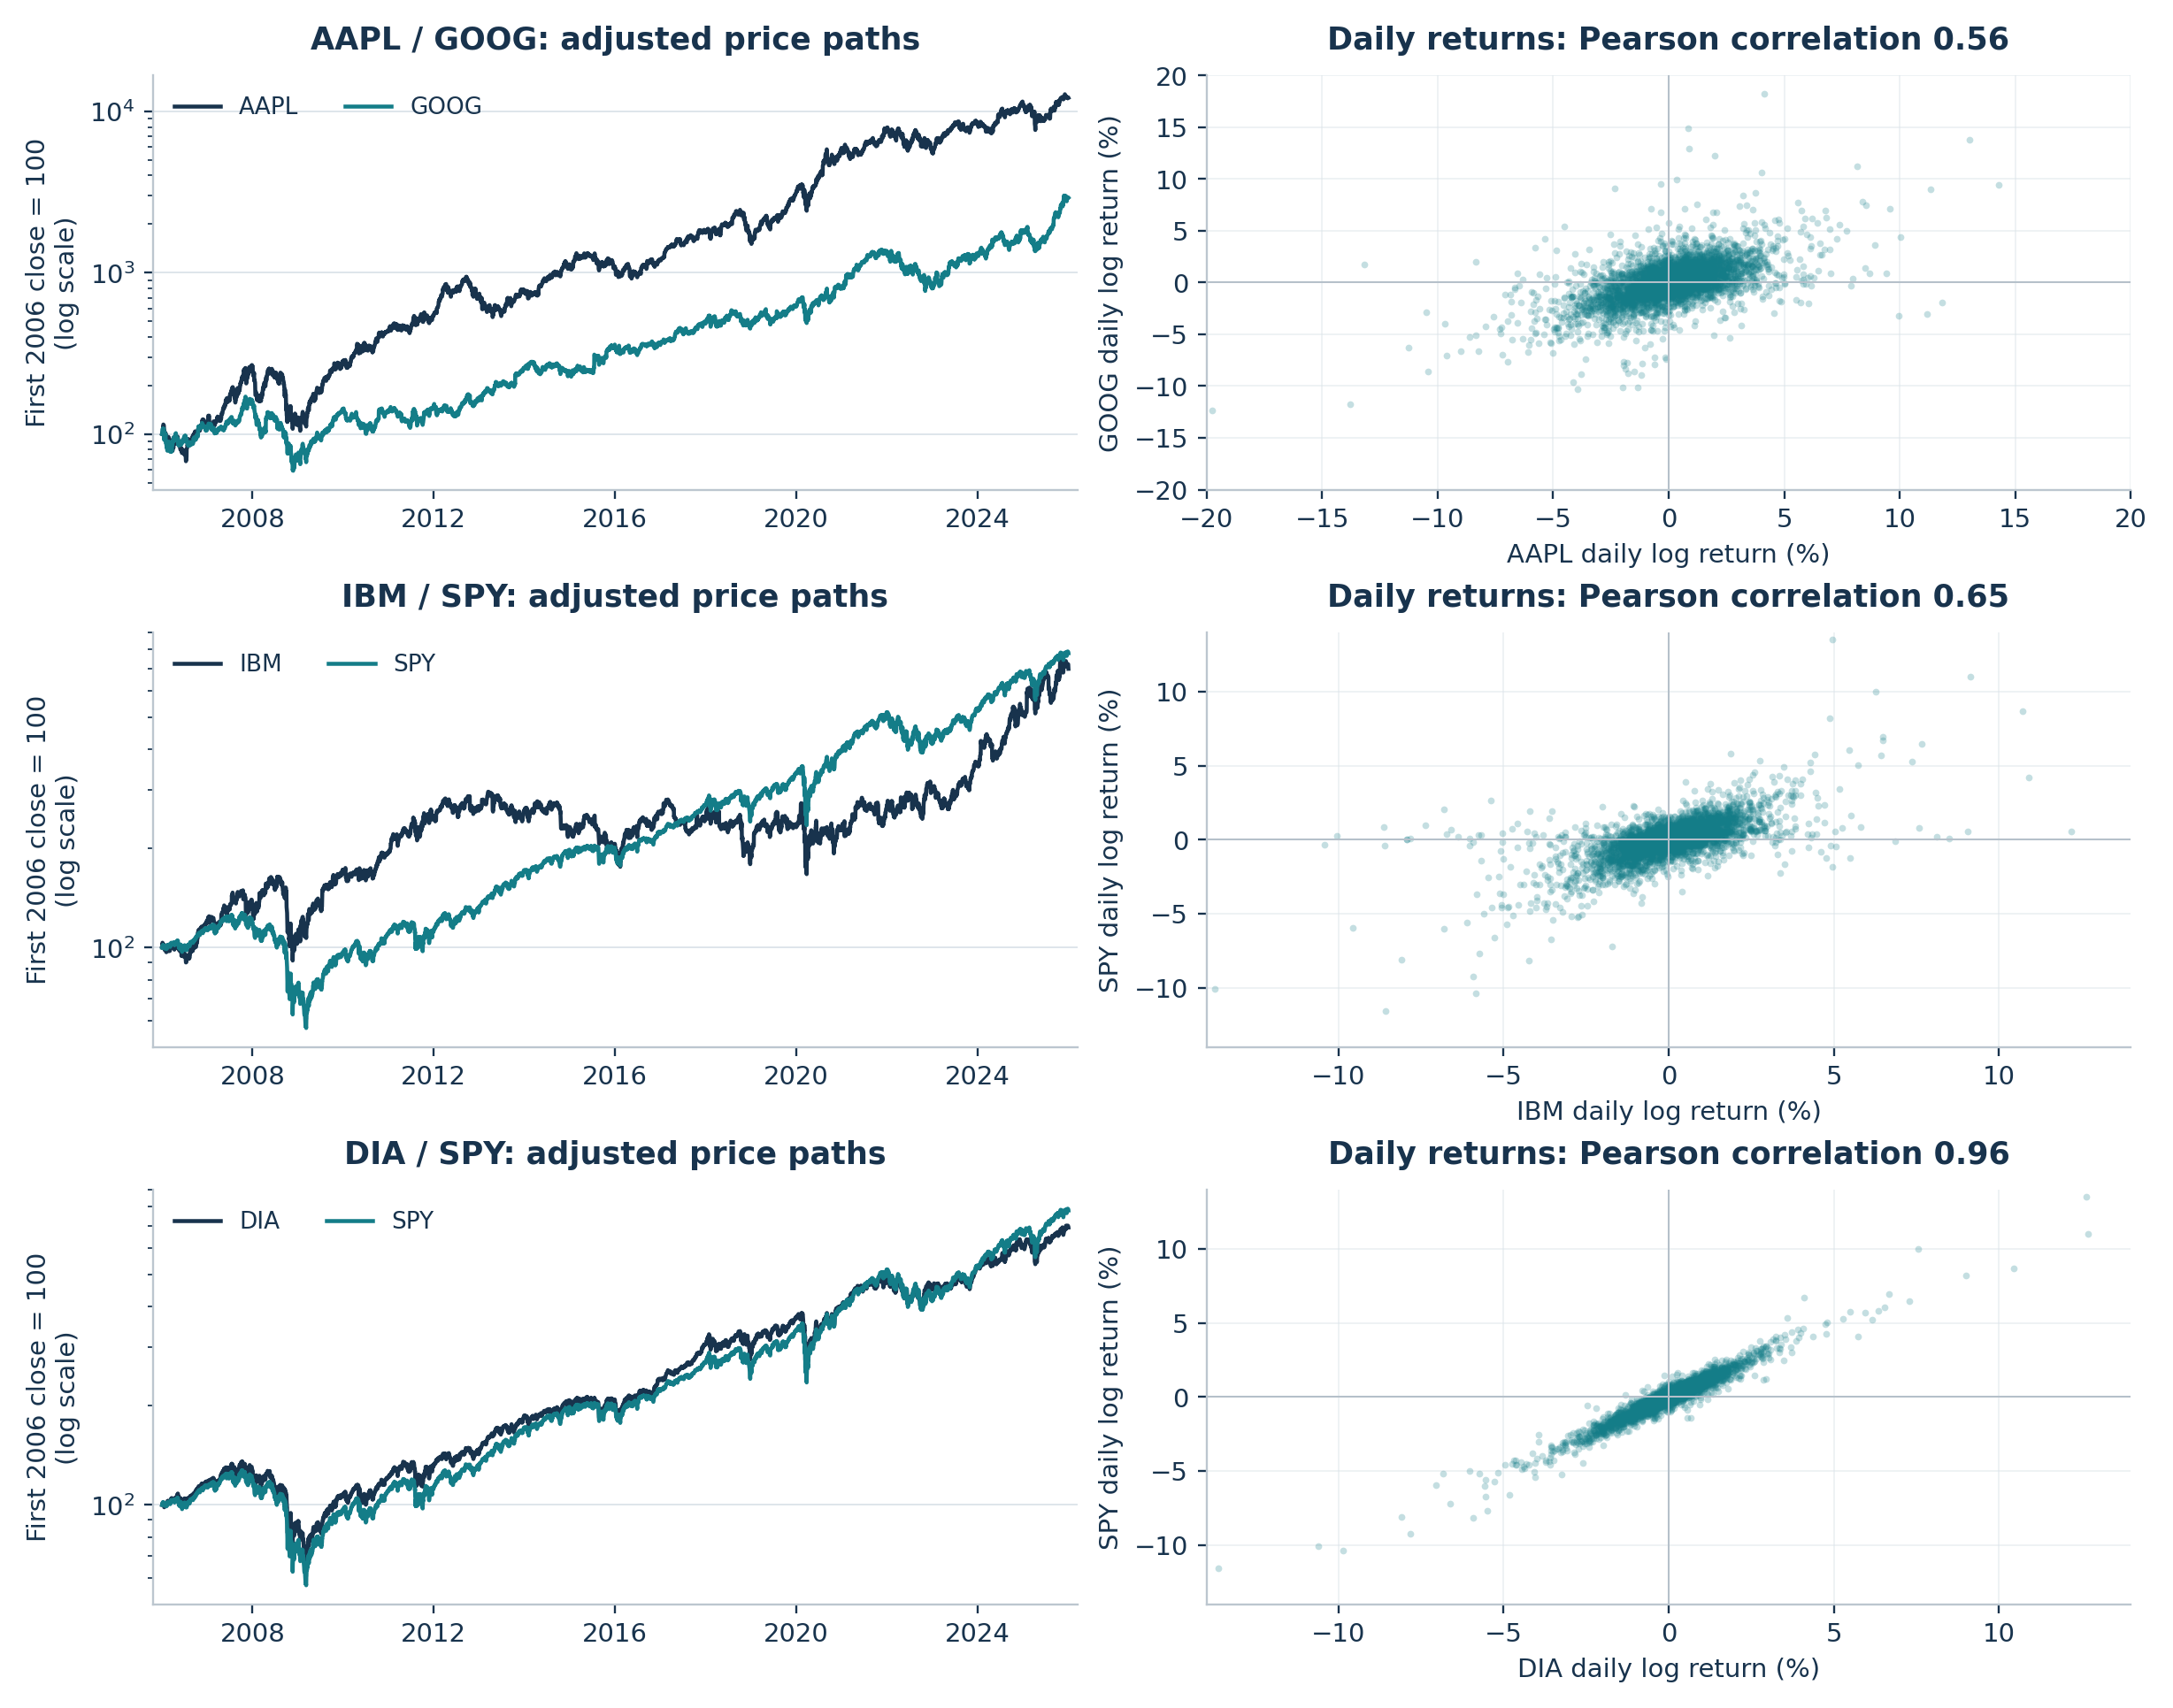

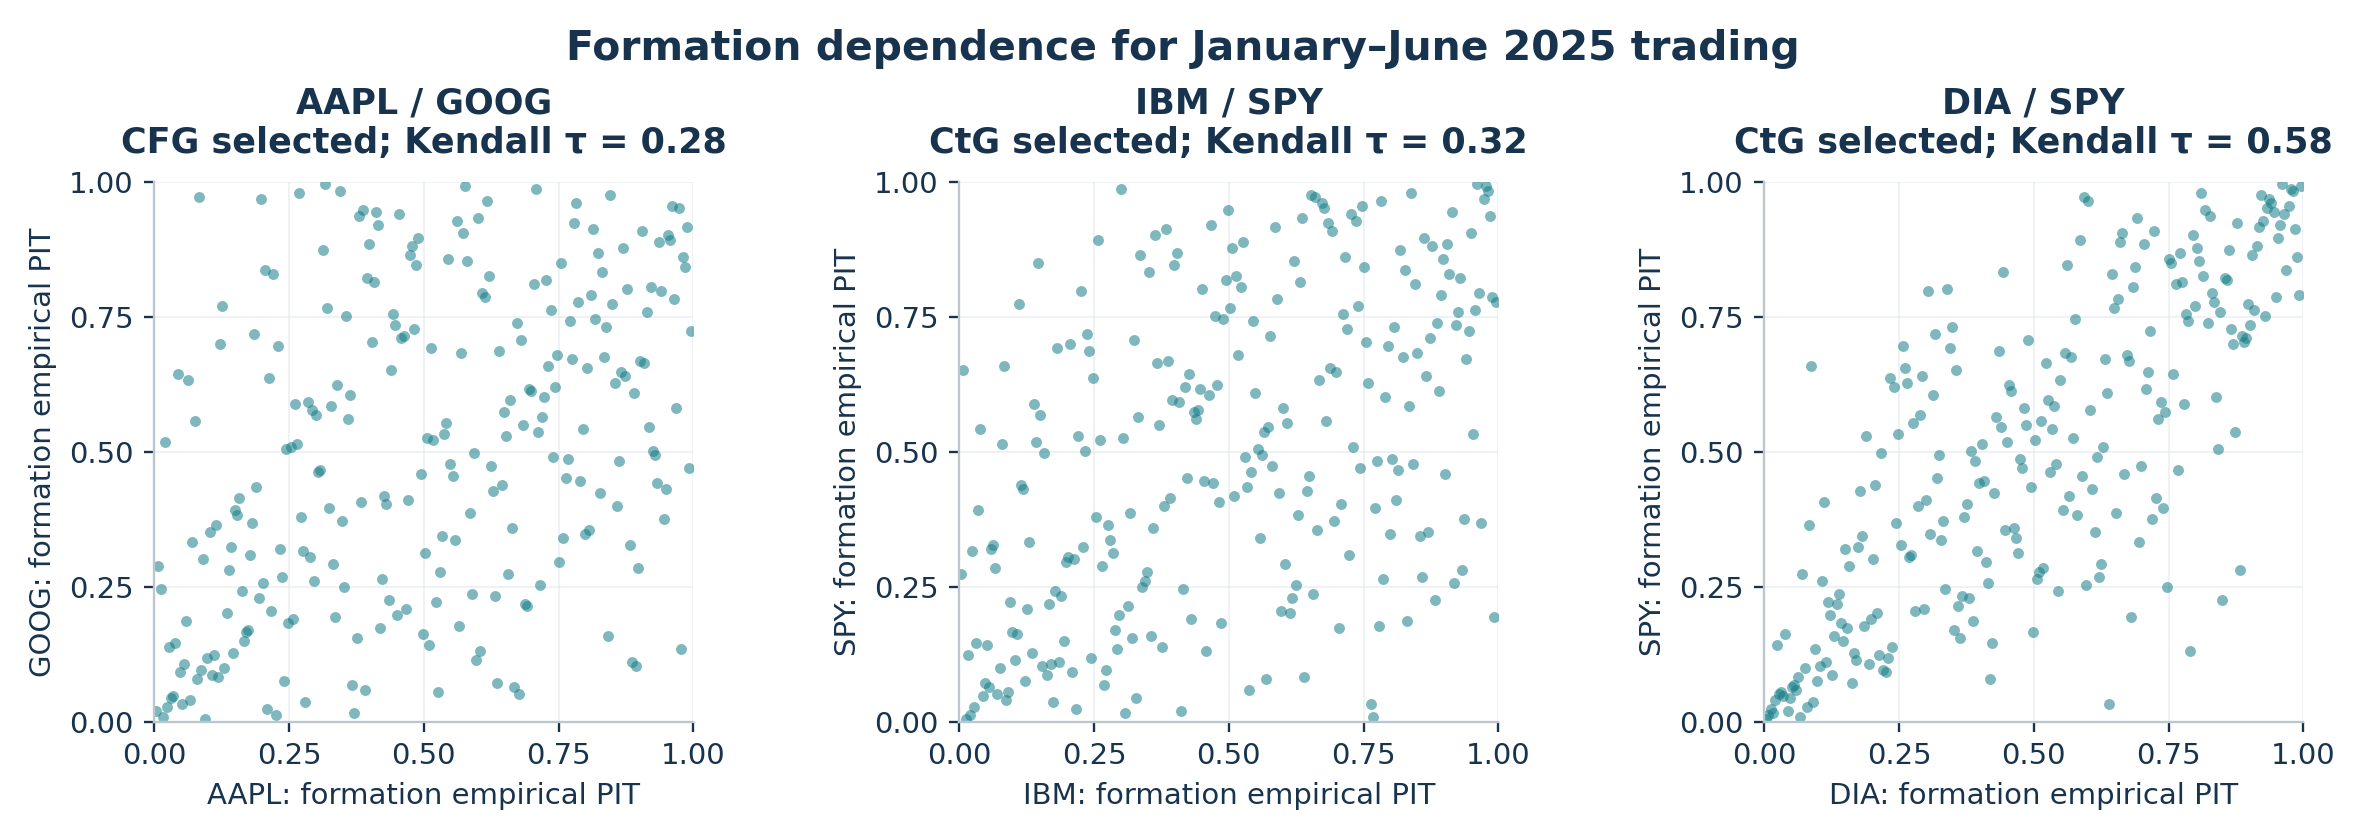

In [9]:
def show_figure(filename):
    path = ROOT / 'report' / 'figures' / filename
    if not path.exists():
        raise FileNotFoundError(f'Missing figure: {path}; build the report figures first.')
    display(Image(filename=str(path), width=1100))

show_figure('context.png')
show_figure('dependence.png')

## 8. Pair and portfolio capital paths

Read each figure's capital convention explicitly. Uncapped fixed-stake
curves show shadow balances and can cross zero; the funded comparison
scales new entries to surviving equity. They include all idle days,
entry/exit costs and forced liquidation at each six-month endpoint.
Separate pair paths reveal whether one assigned relationship dominates
a portfolio result. Fixed-dollar long/short exposure is not guaranteed
market-beta neutrality, and the three sleeves share SPY exposure.

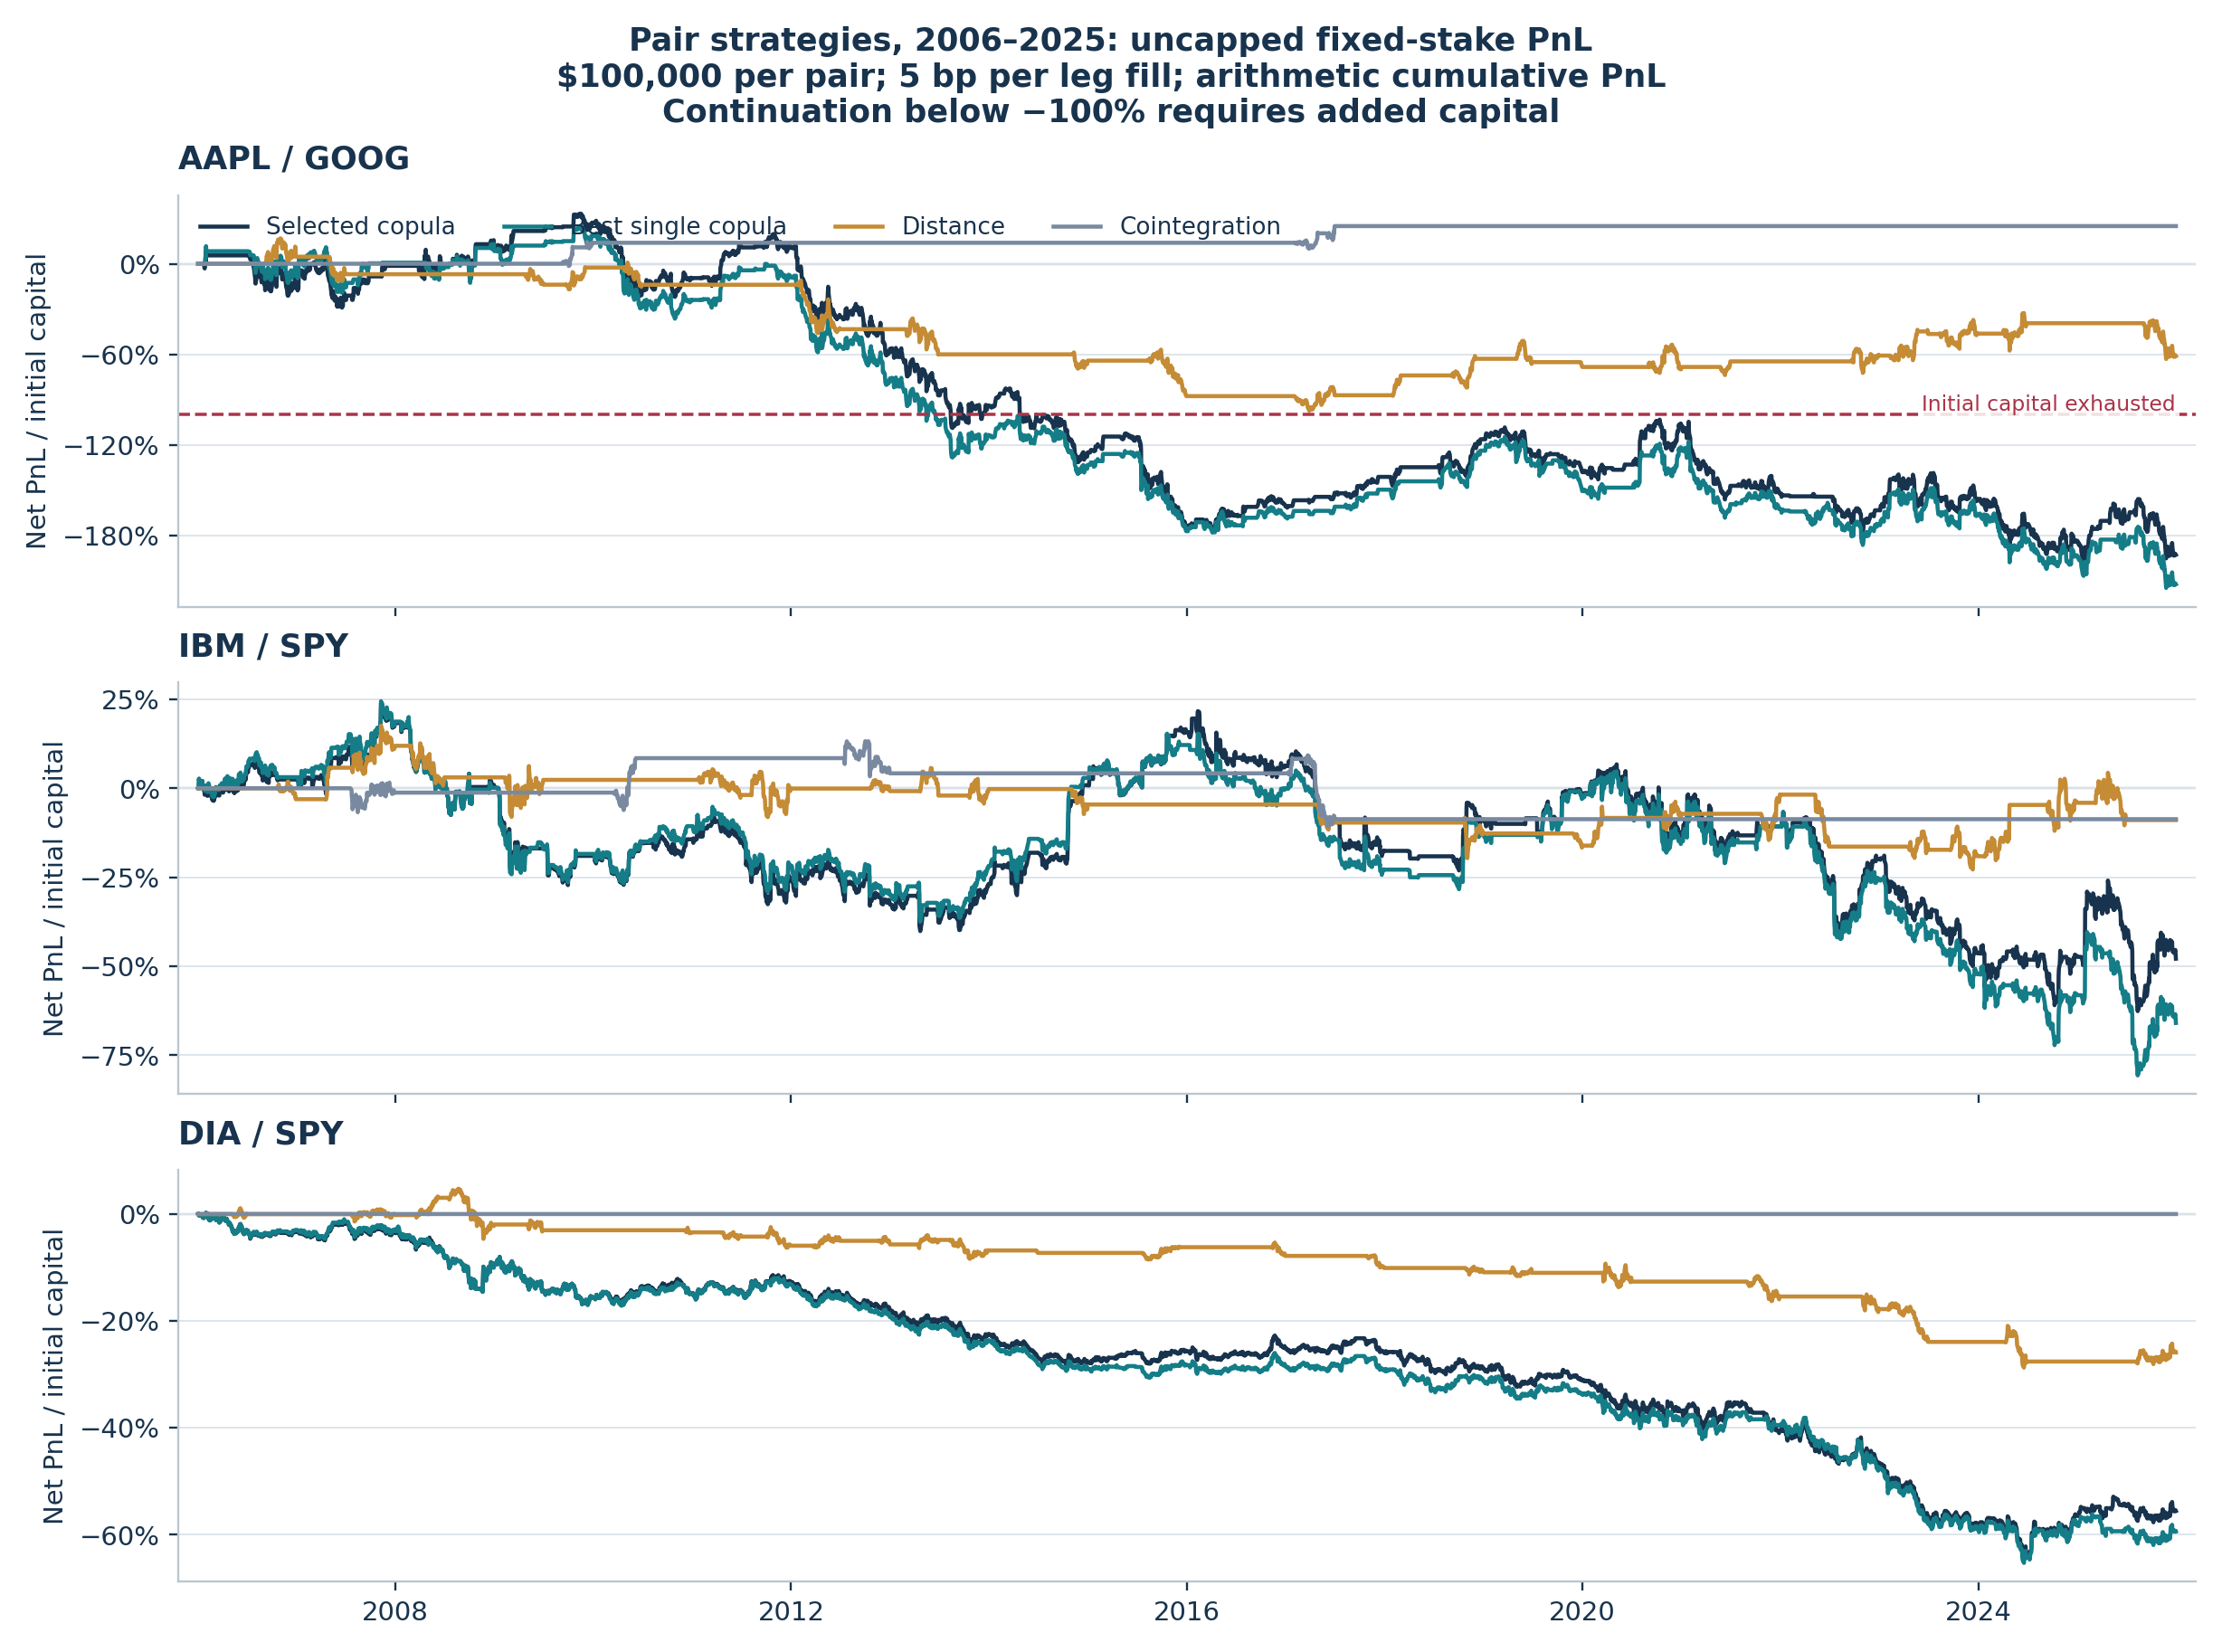

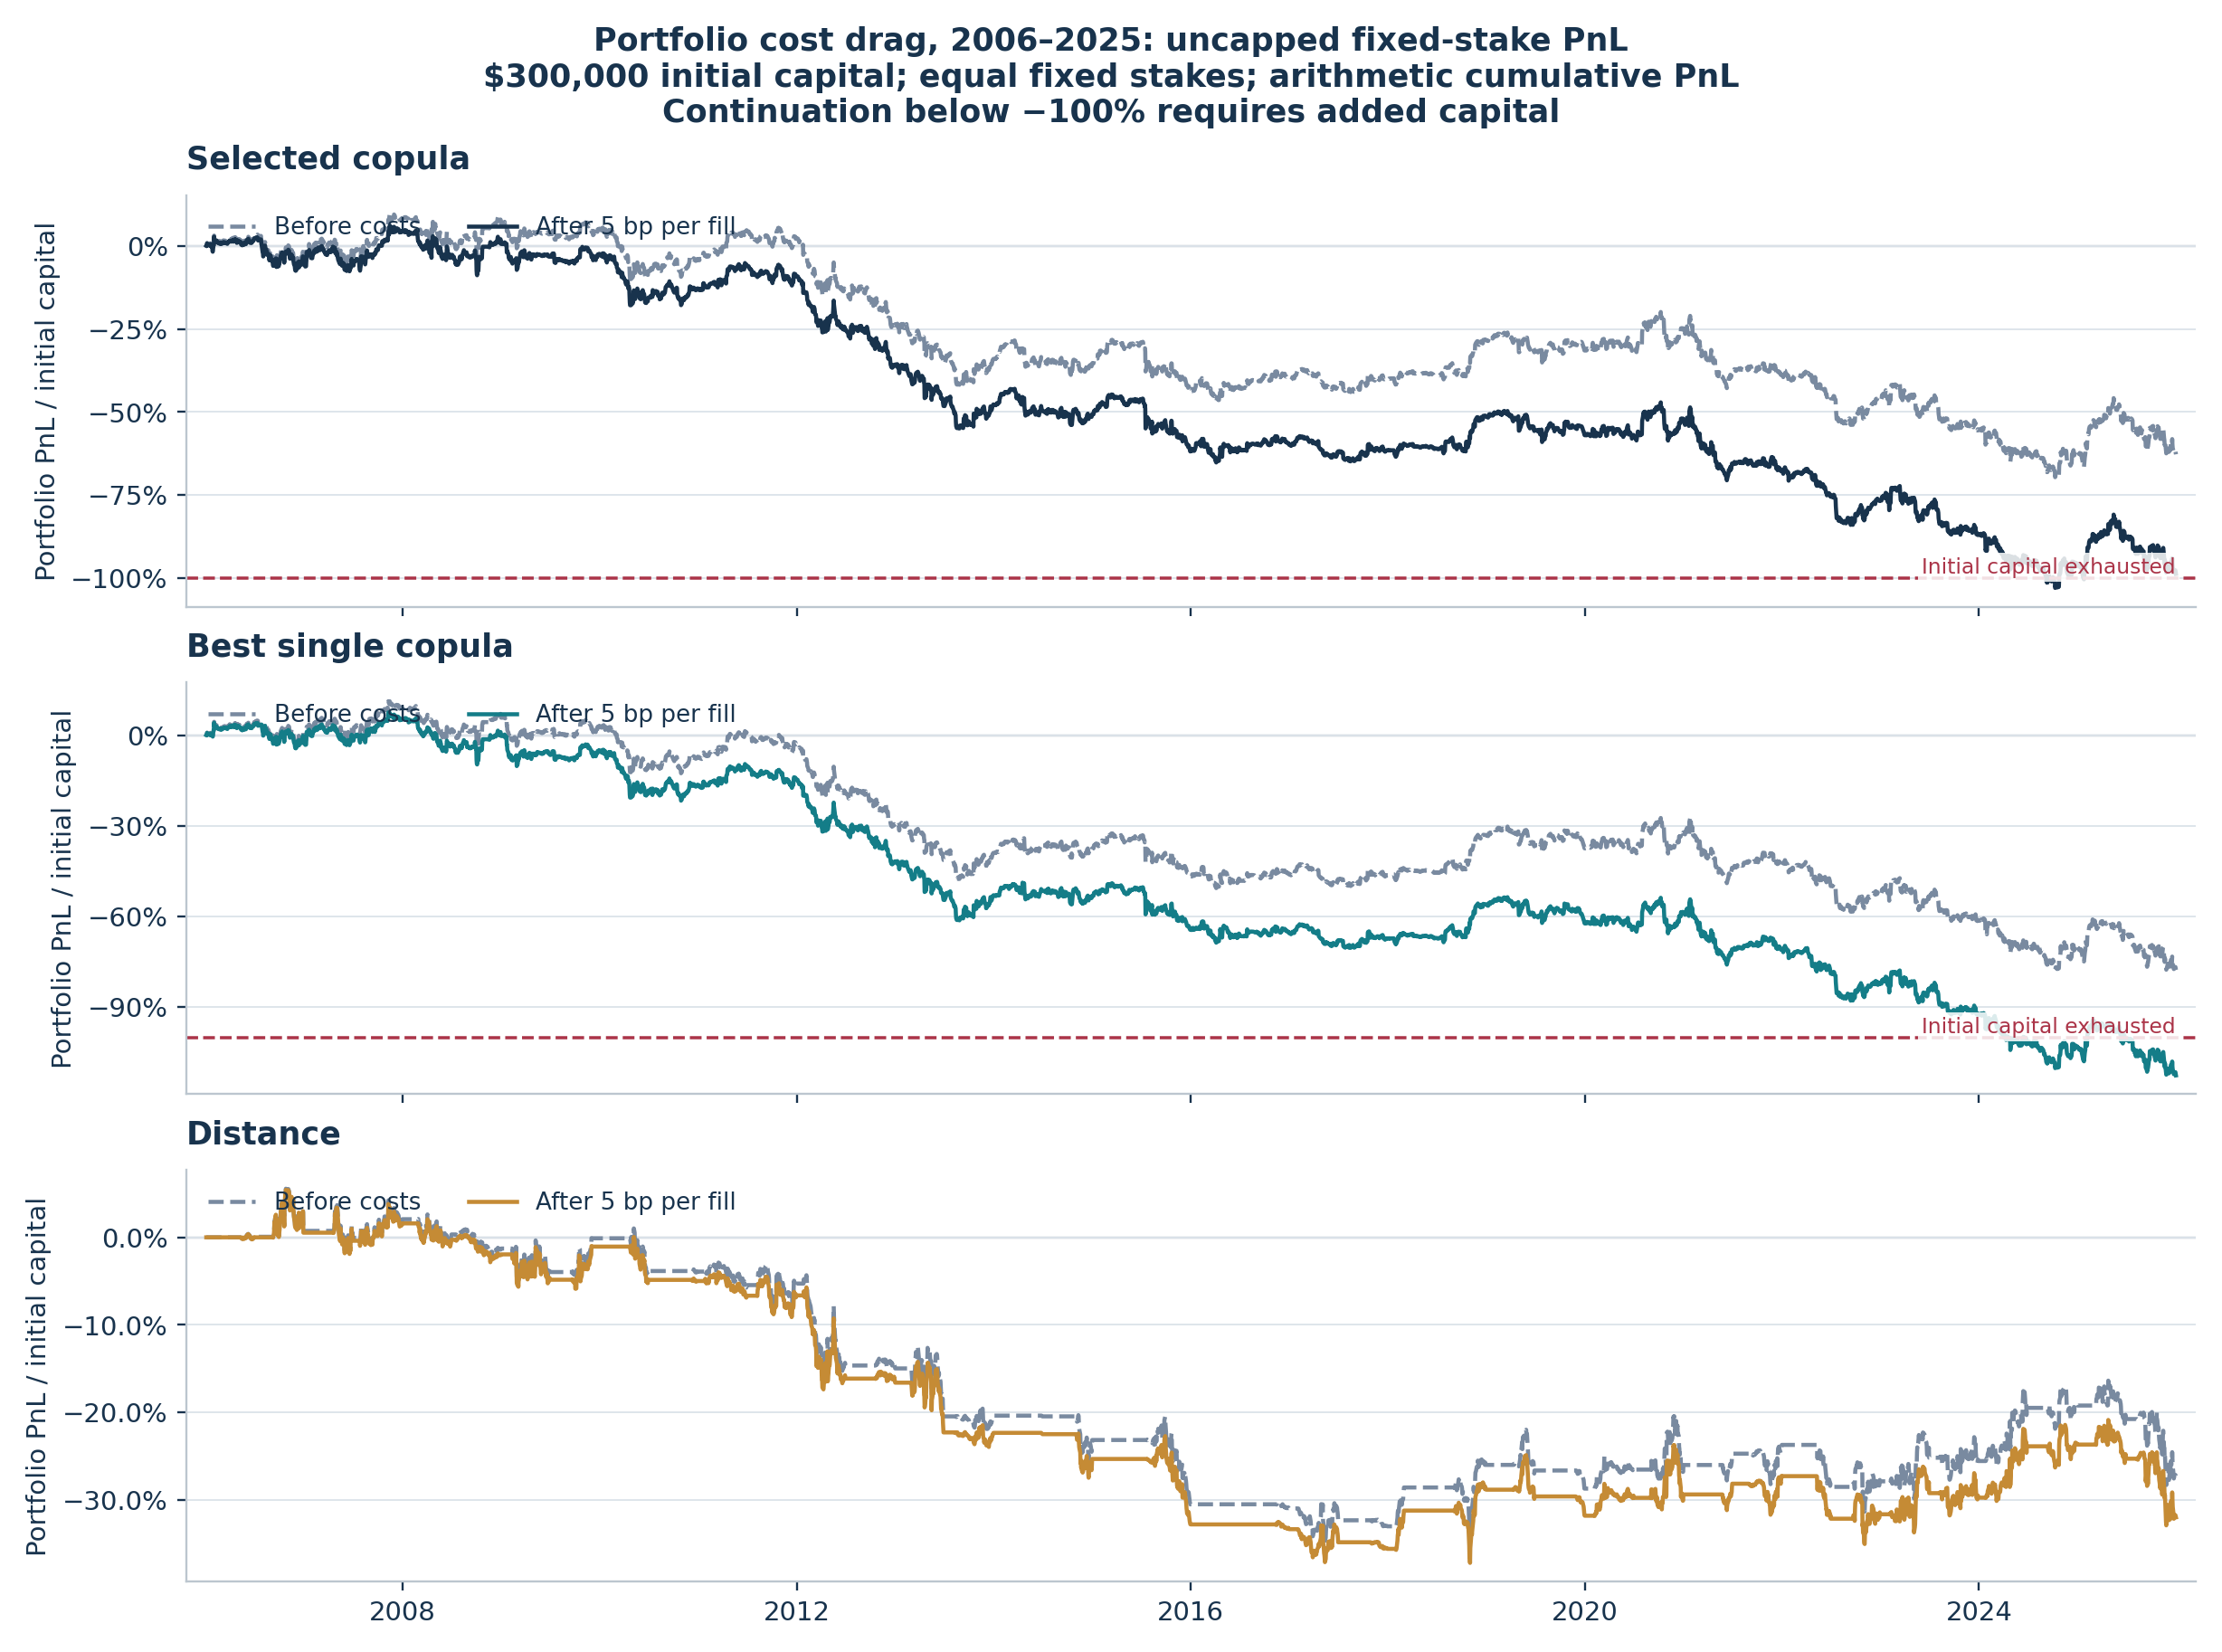

In [10]:
show_figure('pair_equity.png')
show_figure('portfolio_equity.png')

## 9. From conditional ranks to trades

For uniforms $(u,v)$, compute
$h_1=\partial C(u,v)/\partial v$ and
$h_2=\partial C(u,v)/\partial u$.
The flags accumulate $M_{i,t}=M_{i,t-1}+h_{i,t}-0.5$ from zero at each
trading-window start. Enter long first/short second when
$M_1<-0.2$ **and** $M_2>0.2$; reverse the position for the opposite signs.
Flags need not be stationary, and $h_i=0.5$ identifies a modeled
conditional median, not a stock's fundamental fair value.

Paper 1 is inconsistent: its prose says both flags must return to zero,
but its numbered algorithm closes when either does. The baseline follows
the numbered algorithm, interpreting return to zero as a favorable sign
crossing. Flags are not reset after an exit. The alternative both-flag
rule is shown in sensitivity results. All positions close at expiry.

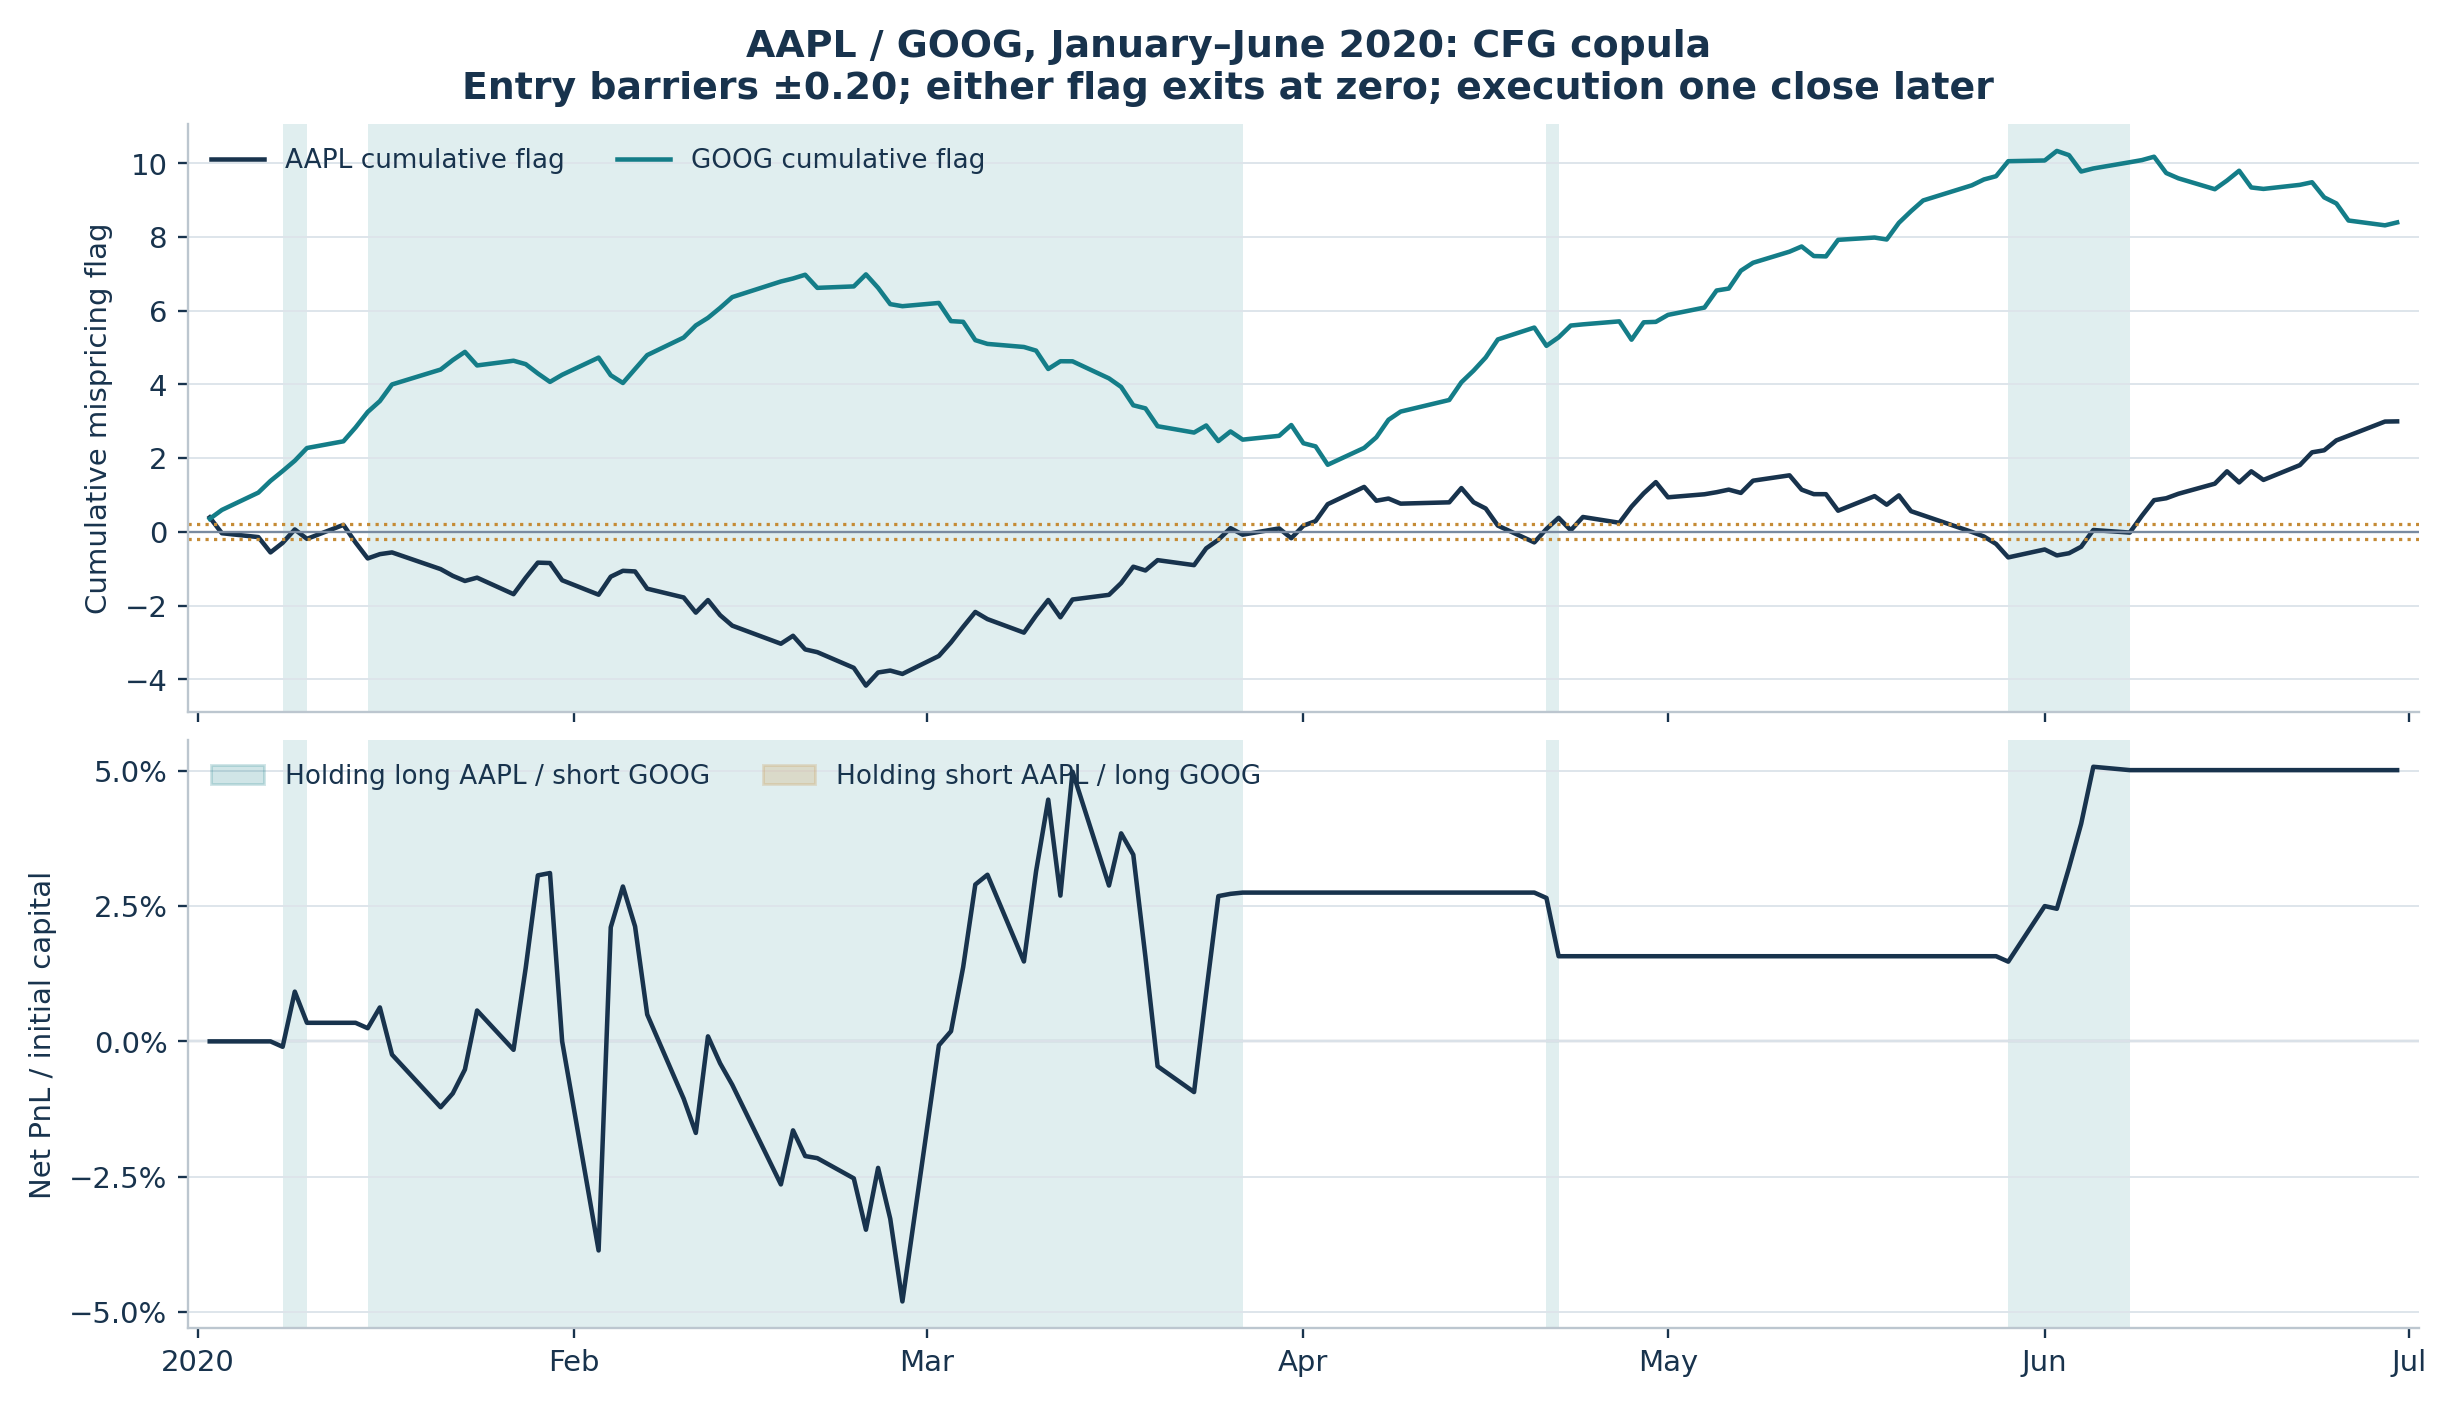

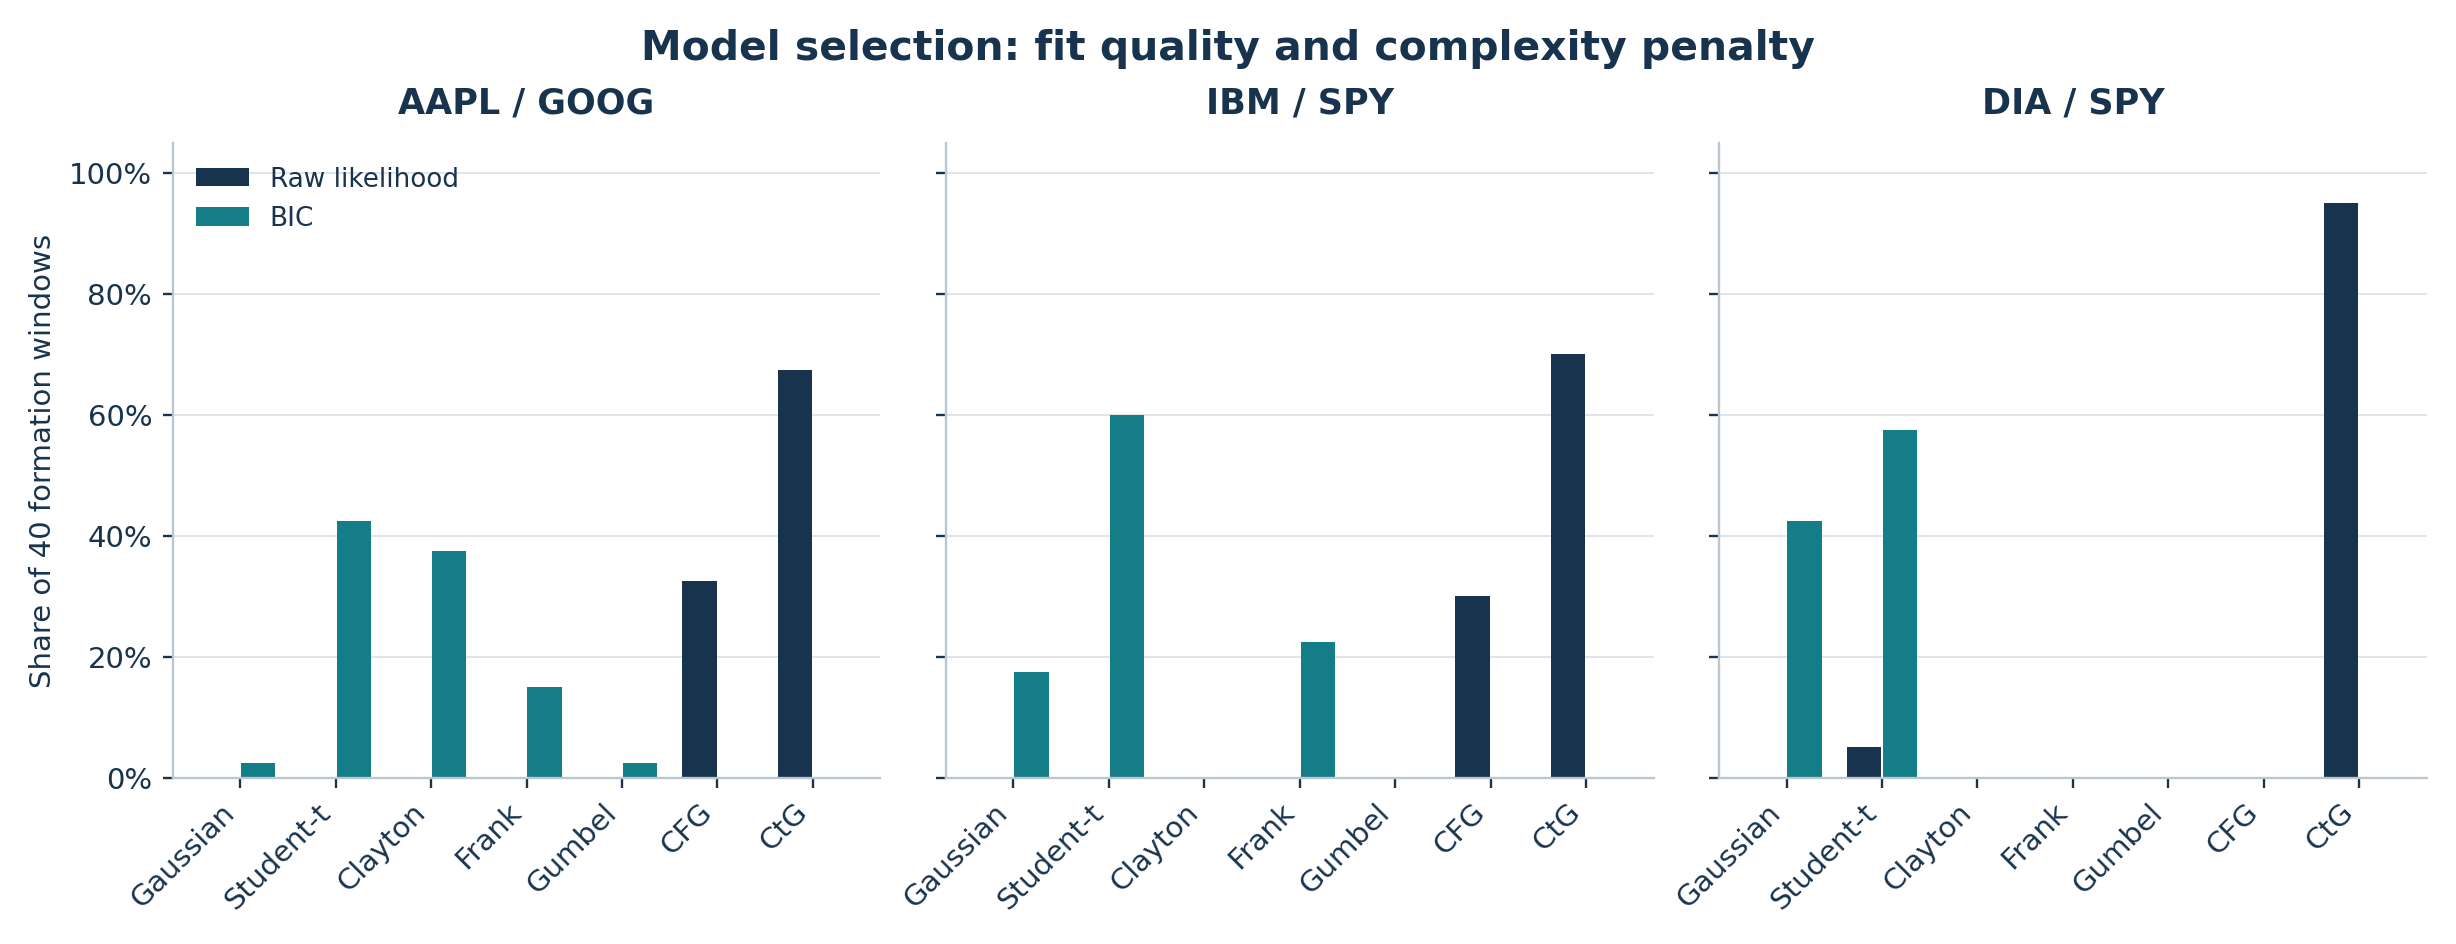

In [11]:
show_figure('signal_example.png')
show_figure('model_selection.png')

## 10. Entry and exit sensitivity

The published ±0.2 entry threshold is fixed before evaluating the new
trading sample. The preset 0.05–0.55 grid and both exit conventions are
sensitivity checks. Their best retrospective result is not promoted
into a newly optimized baseline. The table reports fixed-capital
portfolio totals and annualized mean P&L, not a compounded CAGR.

annual_mean_net_pct  cumulative_portfolio_PnL_pct  \
exit_rule threshold                                                      
both      0.0500                 -5.9145                     -118.0780   
          0.1000                 -5.6181                     -112.1613   
          0.1500                 -5.3599                     -107.0073   
          0.2000                 -5.4538                     -108.8807   
          0.2500                 -5.2666                     -105.1434   
          0.3000                 -5.6228                     -112.2558   
          0.3500                 -5.9284                     -118.3569   
          0.4000                 -6.1012                     -121.8057   
          0.4500                 -5.9329                     -118.4466   
          0.5000                 -6.0609                     -121.0006   
          0.5500                 -5.9249                     -118.2857   
either    0.0500                 -5.9586                     -118.9597   
          0.1000                 -5.4006                     -107.8190   
          0.1500                 -5.2311                     -104.4347   
          0.2000                 -4.9491                      -98.8059   
          0.2500                 -4.5834                      -91.5042   
          0.3000                 -4.3634                      -87.1127   
          0.3500                 -4.2855                      -85.5569   
          0.4000                 -4.5310                      -90.4582   
          0.4500                 -5.1273                     -102.3629   
          0.5000                 -5.1953                     -103.7204   
          0.5500                 -4.7572                      -94.9739   

                     trades  portfolio_turnover  
exit_rule threshold                              
both      0.0500        331            447.6039  
          0.1000        319            431.5472  
          0.1500        306            414.2006  
          0.2000        287            388.8690  
          0.2500        279            378.1703  
          0.3000        267            362.1296  
          0.3500        253            343.4501  
          0.4000        239            324.7958  
          0.4500        229            311.1543  
          0.5000        215            292.2170  
          0.5500        211            286.8753  
either    0.0500        712            953.9887  
          0.1000        657            880.5845  
          0.1500        607            813.9001  
          0.2000        537            720.4949  
          0.2500        492            660.4049  
          0.3000        443            595.0022  
          0.3500        410            550.8615  
          0.4000        373            501.3805  
          0.4500        343            461.0825  
          0.5000        313            421.0307  
          0.5500        301            405.1446

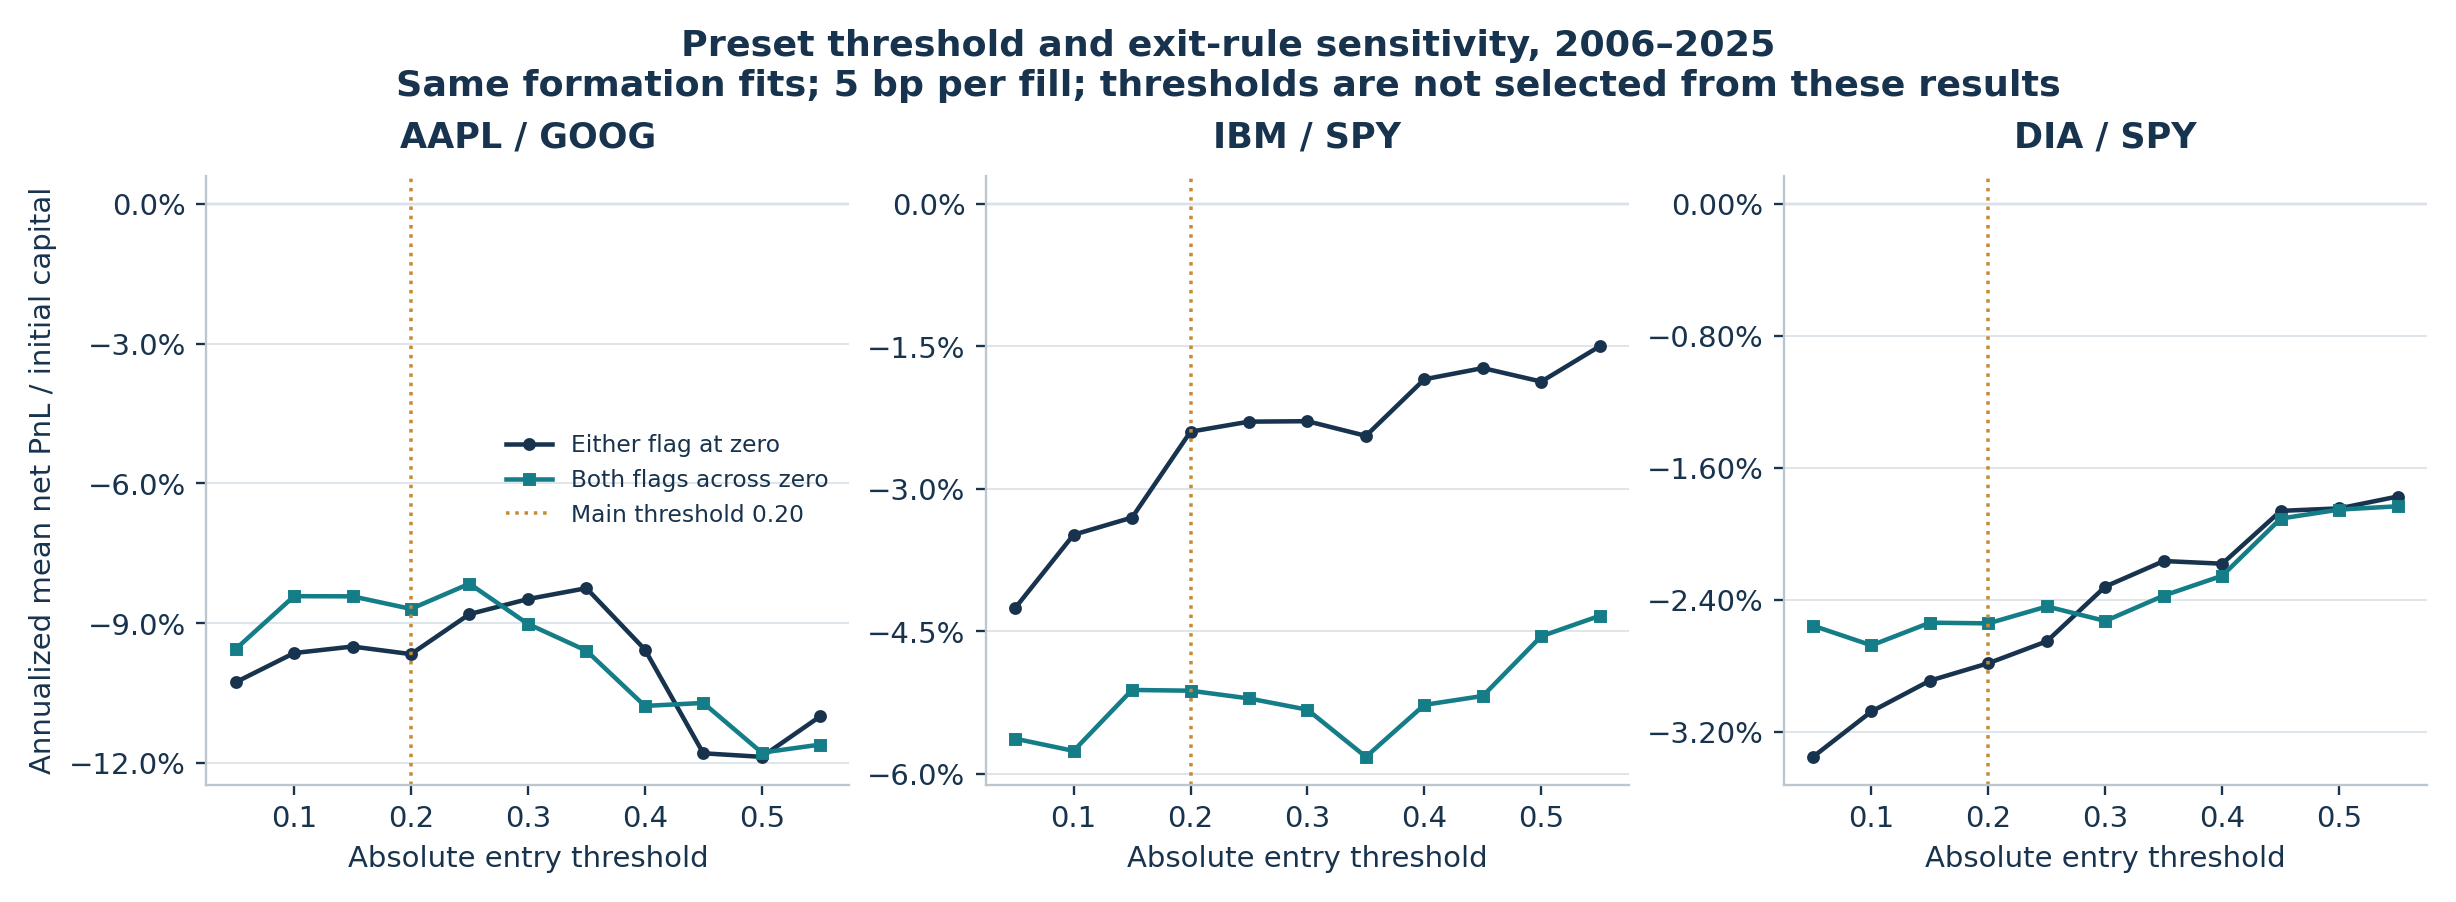

In [12]:
sensitivity = pd.read_csv(RESULTS / 'sensitivity_windows.csv')
threshold_table = sensitivity.groupby(['exit_rule', 'threshold']).agg(
    total_pair_returns=('return_net', 'sum'), total_pair_days=('days', 'sum'),
    trades=('trades', 'sum'), total_pair_turnover=('turnover', 'sum'))
threshold_table['annual_mean_net_pct'] = 100 * 252 * threshold_table.total_pair_returns / threshold_table.total_pair_days
threshold_table['cumulative_portfolio_PnL_pct'] = 100 * threshold_table.total_pair_returns / len(PAIRS)
threshold_table['portfolio_turnover'] = threshold_table.total_pair_turnover / len(PAIRS)
display(threshold_table[['annual_mean_net_pct', 'cumulative_portfolio_PnL_pct', 'trades', 'portfolio_turnover']])
show_figure('threshold_sensitivity.png')

## 11. Trading and stock-borrow costs

Signals and fixed stakes are held unchanged while costs vary. Each
scenario starts from gross P&L, so the 5-bp baseline cost is not deducted
twice. Borrow fees apply to the preceding short marked notional with
252 holding intervals per year. The 14.5-bp-per-fill scenario equals
58 bps per unchanged-notional pair round trip, a transparent comparison
with the literal recent-cost interpretation of paper 2; it is not the
paper's complete historical commission/impact schedule.

,method,cost_bps,borrow_bps,cumulative_pnl_pct,annual_mean_pct,sharpe,algebraic_drawdown_pct
0,Selected,0.0000,0,-62.7812,-3.1447,-0.3158,-72.3485
1,Selected,1.0000,0,-69.9861,-3.5056,-0.3520,-78.2892
2,Selected,5.0000,0,-98.8059,-4.9491,-0.4969,-102.8583
3,Selected,5.0000,100,-114.5162,-5.7361,-0.5759,-116.8880
4,Selected,5.0000,300,-145.9367,-7.3099,-0.7339,-145.7696
5,Selected,10.0000,0,-134.8307,-6.7536,-0.6774,-135.5069
6,Selected,14.5000,0,-167.2529,-8.3776,-0.8391,-165.7790
7,Selected,20.0000,0,-206.8802,-10.3625,-1.0353,-204.8773
8,Best-single,0.0000,0,-77.6774,-3.8908,-0.4023,-79.9371
9,Best-single,1.0000,0,-84.6642,-4.2408,-0.4385,-86.1242


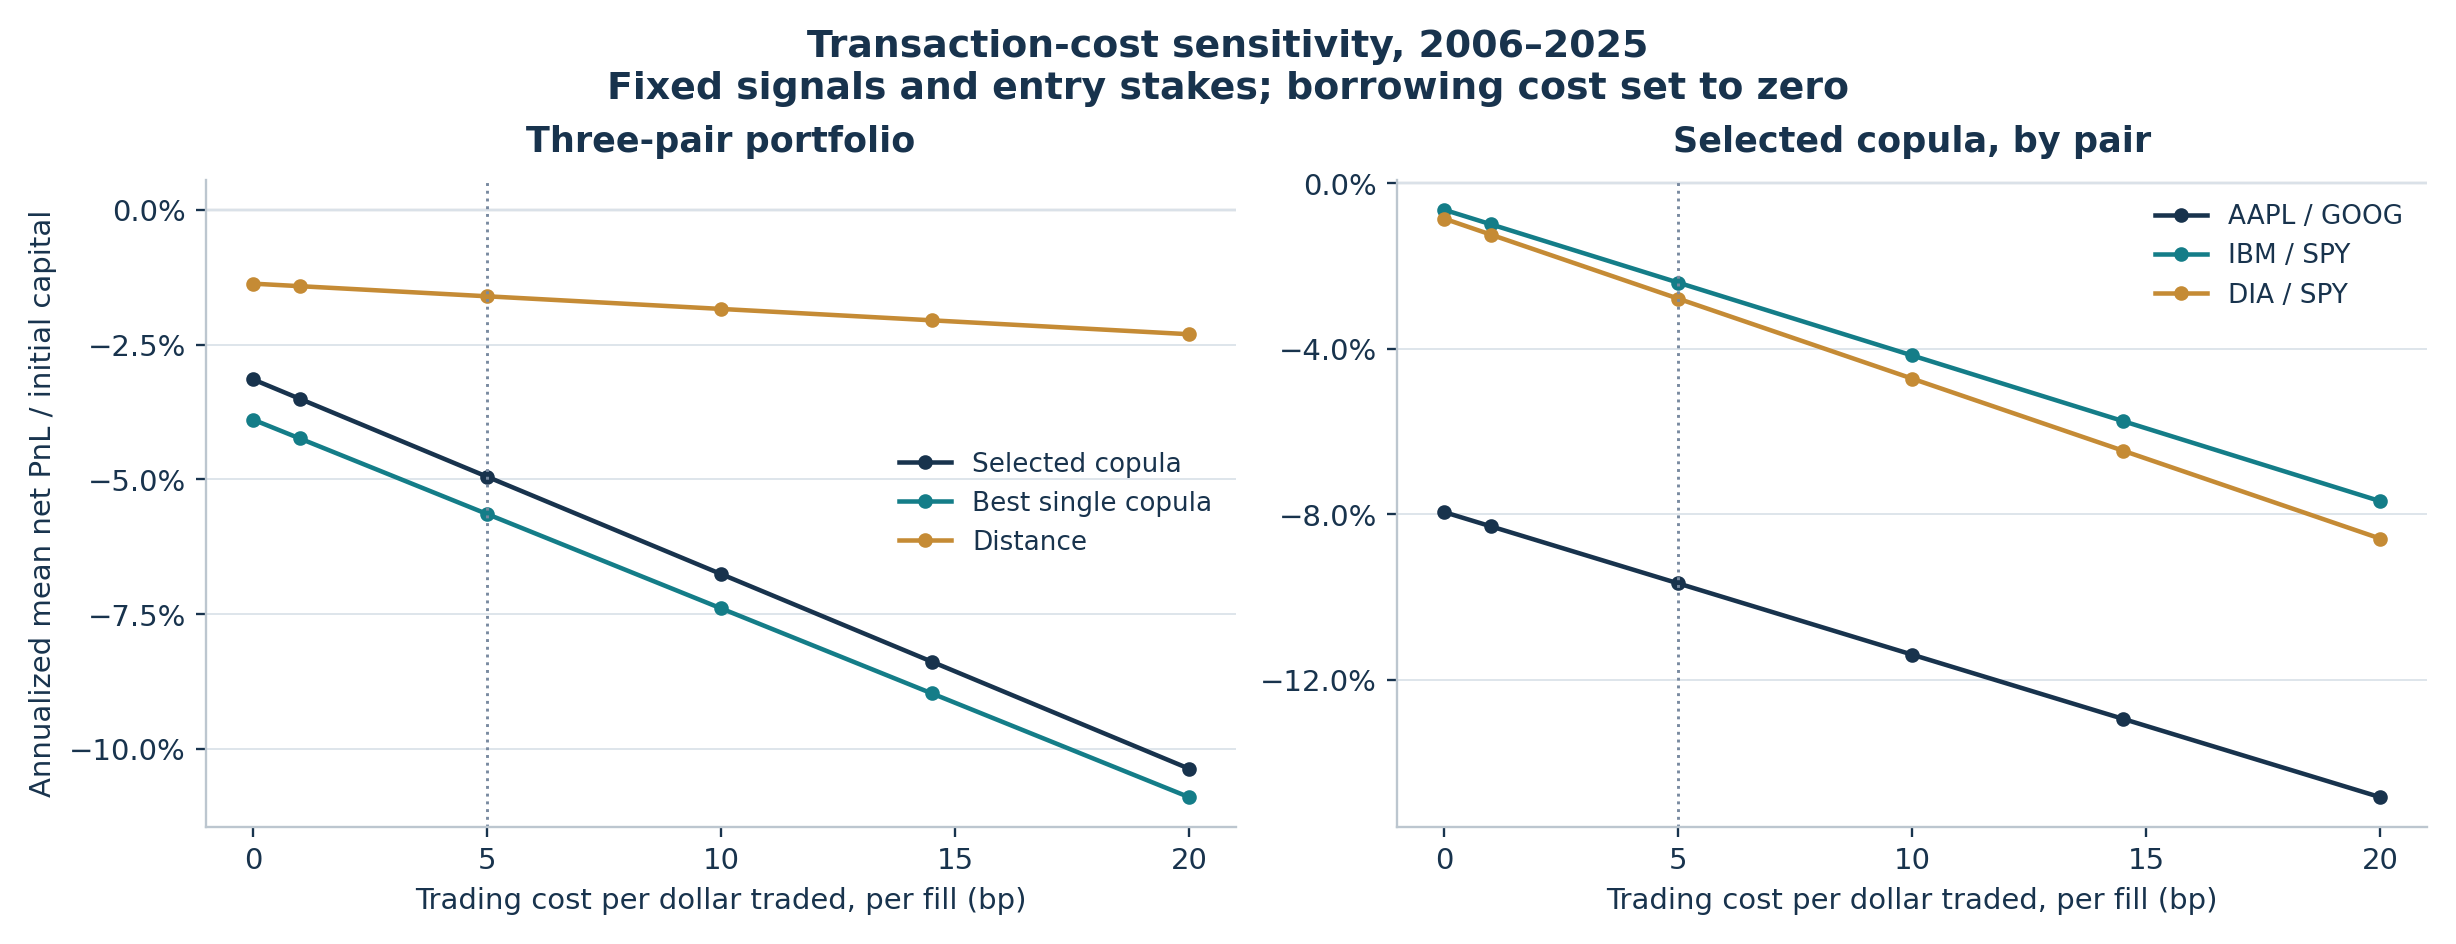

In [13]:
costs = pd.read_csv(RESULTS / 'cost_sensitivity.csv')
display(costs.loc[costs.pair.eq('Portfolio'),
                 ['method', 'cost_bps', 'borrow_bps', 'cumulative_pnl_pct',
                  'annual_mean_pct', 'sharpe', 'max_drawdown_pct']]
        .rename(columns={'max_drawdown_pct': 'algebraic_drawdown_pct'}).reset_index(drop=True))
show_figure('cost_sensitivity.png')

## 12. Chronological stability

The chronological slices describe how performance changes across
economic regimes. They are reporting periods and were not used to choose
parameters. The full baseline remains the same throughout.

In [14]:
subperiods = pd.read_csv(RESULTS / 'subperiods.csv')
display(subperiods[['period', 'method', 'annual_mean_pct', 'annual_vol_pct',
                   'sharpe', 'cumulative_pnl_pct', 'max_drawdown_pct']]
        .rename(columns={'max_drawdown_pct': 'algebraic_drawdown_pct'}))

,period,method,annual_mean_pct,annual_vol_pct,sharpe,cumulative_pnl_pct,algebraic_drawdown_pct
0,2006-2015,Selected,-6.1818,10.0983,-0.6122,-61.7440,-64.1155
1,2006-2015,Best-single,-6.4520,9.6192,-0.6707,-64.4428,-66.9417
2,2006-2015,BIC,-6.7598,9.5969,-0.7044,-67.5175,-69.3987
3,2006-2015,Distance,-3.2881,5.6951,-0.5774,-32.8423,-36.3008
4,2006-2015,Cointegration,0.6034,2.0226,0.2983,6.0263,-3.0197
5,2016-2025,Selected,-3.7150,9.8220,-0.3782,-37.0619,-48.7744
6,2016-2025,Best-single,-4.8283,9.7264,-0.4964,-48.1685,-53.2343
7,2016-2025,BIC,-4.6449,9.7289,-0.4774,-46.3380,-51.5668
8,2016-2025,Distance,0.0810,5.9020,0.0137,0.8084,-10.7708
9,2016-2025,Cointegration,-0.0608,1.5002,-0.0405,-0.6061,-5.6336


## 13. Uncertainty and dependence

Monthly mean t-statistics use HAC standard errors with six **monthly**
lags. This is a declared reporting choice, distinct from paper 1's
six-daily-lag procedure. A seeded circular moving-block bootstrap uses
six-month blocks and 5,000 replications for differences between the
selected-copula portfolio and preset comparators. It is a descriptive
interval, not paper 1's stationary bootstrap with automatic block
selection and not a correction for testing many strategies.

In [15]:
display(performance.loc[performance.pair.eq('Portfolio') & performance.basis.eq('net'),
                        ['method', 'monthly_mean_bps', 'monthly_hac_t', 'monthly_hac_p',
                         'negative_month_pct']].reset_index(drop=True))
intervals = pd.DataFrame(audit['bootstrap_intervals']).T
intervals.index.name = 'Selected_minus_comparator'
display(intervals)

,method,monthly_mean_bps,monthly_hac_t,monthly_hac_p,negative_month_pct
0,Selected,-41.1691,-2.4097,0.0160,55.8333
1,Best-single,-46.9214,-2.7990,0.0051,57.0833
2,BIC,-47.4398,-2.8441,0.0045,57.5000
3,Gaussian,-45.1400,-2.5569,0.0106,55.8333
4,Student-t,-44.3505,-2.4579,0.0140,57.0833
5,Clayton,-44.3408,-2.8129,0.0049,53.3333
6,Frank,-50.6700,-3.1474,0.0016,56.2500
7,Gumbel,-34.5064,-1.9733,0.0485,51.2500
8,CFG,-41.9426,-2.3776,0.0174,55.8333
9,CtG,-41.3104,-2.3926,0.0167,55.8333


,mean_monthly_difference_bps,lower95_bps,upper95_bps,reps,block_months,seed
Selected_minus_comparator,,,,,,
Distance,-27.8217,-58.6398,2.4403,"5,000.0000",6.0000,"2,606.0000"
Best-single,5.7523,-2.9069,14.3586,"5,000.0000",6.0000,"2,606.0000"
BIC,6.2707,-2.0872,15.2359,"5,000.0000",6.0000,"2,606.0000"


## 14. Accounting and provenance checks

Daily marked-to-market P&L must reconcile to the completed-trade ledger.
Baseline net P&L must equal gross less transaction costs and borrow fees
exactly once. All fitted windows must still match the recorded input and
model hashes. These checks complement unit tests of conditional
probabilities, causal filtering, signal timing and hand-computed trades.

In [16]:
grouped_daily = daily.groupby(['method', 'pair']).pnl_net.sum()
grouped_trades = trades.groupby(['method', 'pair']).pnl_net.sum().reindex(grouped_daily.index, fill_value=0)
reconciliation = float((grouped_daily - grouped_trades).abs().max())
np.testing.assert_allclose(grouped_daily, grouped_trades, atol=1e-6, rtol=1e-9)
np.testing.assert_allclose(daily.pnl_net,
                           daily.pnl_gross - daily.transaction_cost - daily.borrow_cost,
                           atol=1e-8, rtol=1e-10)
current_signature = fingerprint()
assert all(cache['fingerprint'] == current_signature for cache in load_cache())
assert audit['all_marginals_converged'] and audit['all_copula_models_success']
print('Daily/trade maximum absolute difference, USD:', reconciliation)
print('Verified fitted windows:', audit['windows'])
print('OOS trading days:', audit['oos_days'])
print('Minimum uncapped shadow balance per initial dollar:', audit['minimum_baseline_equity_per_initial_dollar'])
print('All supplementary equity-funded account balances positive:', funded_daily.equity_per_initial_dollar.gt(0).all())
display(pd.Series(audit['design'], name='Implemented convention').to_frame())

Daily/trade maximum absolute difference, USD: 5.820766091346741e-11
Verified fitted windows: 40
OOS trading days: 5031
Minimum uncapped shadow balance per initial dollar: -1.281420688634837
All supplementary equity-funded account balances positive: True


,Implemented convention
stake_per_pair,100000
cost_bps_per_leg_fill,5
lag_closes,1
main_entry_threshold,0.2000
main_exit,either
reset_flags,window only
return_convention,"fixed initial long-side capital; arithmetic, n..."


## 15. What the experiment establishes

The following conclusions are constructed from the executed results.
The papers' published profits are literature comparisons, not numerical
targets imposed on these data. Paper 1 reported top-five net committed
annual mean excess returns of 3.68% for mixed copulas versus 2.30% for
distance. Paper 2 reported net monthly employed-capital means of 0.38%,
0.33% and 0.05% for distance, cointegration and copula, respectively.
Different pairs, periods, costs, capital conventions and window designs
prevent interpreting differences from those figures as a coding error.

In [17]:
net_portfolio = performance.loc[performance.pair.eq('Portfolio') & performance.basis.eq('net')].set_index('method')
selected = net_portfolio.loc['Selected']
distance = net_portfolio.loc['Distance']
funded_selected = funded.loc[funded.method.eq('Selected') & funded.pair.eq('Portfolio')].iloc[0]
selected_pairs = performance.loc[performance.method.eq('Selected') & performance.basis.eq('net') & performance.pair.ne('Portfolio')]
positive_pairs = int(selected_pairs.cumulative_pnl_pct.gt(0).sum())
mixed_share = 100 * fits.loc[fits.selected, 'family'].isin(['CFG', 'CtG']).mean()
difference = intervals.loc['Distance']
interval_text = ('contains zero' if difference.lower95_bps <= 0 <= difference.upper95_bps
                 else 'excludes zero for this prespecified comparison')
result_direction = 'positive' if selected.cumulative_pnl_pct > 0 else 'negative' if selected.cumulative_pnl_pct < 0 else 'zero'
display(Markdown(f'''
The supplementary **equity-at-entry selected-copula portfolio** finishes
with **{funded_selected.final_equity_per_initial_dollar:.4f} dollars per initial dollar**,
a total net return of **{funded_selected.cumulative_return_pct:.2f}%**,
CAGR **{funded_selected.cagr_pct:.2f}%**, and maximum drawdown
**{funded_selected.max_drawdown_pct:.2f}%** under its stated financing assumptions.

The separate **uncapped fixed-stake** diagnostic has {result_direction}
cumulative net P&L of **{selected.cumulative_pnl_pct:.2f}%** of original
committed capital. Its annualized mean contribution is **{selected.annual_mean_pct:.2f}%**,
Sharpe **{selected.sharpe:.2f}**, and **algebraic** drawdown **{selected.max_drawdown_pct:.2f}%**.
Distance's annualized mean is **{distance.annual_mean_pct:.2f}%** with Sharpe
**{distance.sharpe:.2f}**. These uncapped fixed-stake statistics are not
compounded CAGRs or evidence that the strategy remains funded after
capital exhaustion. The funding-failure table gives the relevant dates.

**{positive_pairs} of the 3** selected-copula pair sleeves have positive
cumulative net P&L. Mixtures win **{mixed_share:.1f}%** of formation
log-likelihood comparisons. That frequency describes in-sample fit,
while the tables above establish the realized trading outcomes.

The six-month-block 95% interval for the selected-minus-distance monthly
mean difference is **[{difference.lower95_bps:.2f}, {difference.upper95_bps:.2f}] bps**
and {interval_text}. The interval has the stated descriptive limitations.

This experiment completes the three assigned pairs, seven dependence
families, marginal filtering, distance and screened cointegration
comparisons, paper-style marked-to-market P&L, capital denominators,
and preset cost/entry/exit checks. Its small preselected universe,
idealized closing fills, synthetic adjusted-price units, omitted baseline
financing/borrow constraints and model-search comparisons limit broader
profitability claims. The evidence does not establish risk-free arbitrage.
'''))


The supplementary **equity-at-entry selected-copula portfolio** finishes
with **0.3693 dollars per initial dollar**,
a total net return of **-63.07%**,
CAGR **-4.87%**, and maximum drawdown
**-66.90%** under its stated financing assumptions.

The separate **uncapped fixed-stake** diagnostic has negative
cumulative net P&L of **-98.81%** of original
committed capital. Its annualized mean contribution is **-4.95%**,
Sharpe **-0.50**, and **algebraic** drawdown **-102.86%**.
Distance's annualized mean is **-1.60%** with Sharpe
**-0.28**. These uncapped fixed-stake statistics are not
compounded CAGRs or evidence that the strategy remains funded after
capital exhaustion. The funding-failure table gives the relevant dates.

**0 of the 3** selected-copula pair sleeves have positive
cumulative net P&L. Mixtures win **98.3%** of formation
log-likelihood comparisons. That frequency describes in-sample fit,
while the tables above establish the realized trading outcomes.

The six-month-block 95% interval for the selected-minus-distance monthly
mean difference is **[-58.64, 2.44] bps**
and contains zero. The interval has the stated descriptive limitations.

This experiment completes the three assigned pairs, seven dependence
families, marginal filtering, distance and screened cointegration
comparisons, paper-style marked-to-market P&L, capital denominators,
and preset cost/entry/exit checks. Its small preselected universe,
idealized closing fills, synthetic adjusted-price units, omitted baseline
financing/borrow constraints and model-search comparisons limit broader
profitability claims. The evidence does not establish risk-free arbitrage.


## Reproduction files

- `src/marginals.py`, `src/copulas.py`: formation estimation and conditional probabilities.
- `src/signals.py`, `src/backtest.py`, `src/metrics.py`: signals, holdings, P&L and statistics.
- `scripts/download_data.py`, `scripts/fit_models.py`, `scripts/run_analysis.py`: the pipeline.
- `data_manifest.json`: source provenance and original-data hashes.
- `results/*.csv`, `results/audit.json`: the numerical tables, ledgers and checks.
- `tests/`: mathematical, timing, capital and accounting checks (`python -m pytest -q`).

Install the pinned dependencies with `python -m pip install -r requirements.txt`.
Run the download, fitting and analysis scripts in that order for a clean
reproduction. The notebook reuses verified cached fits. Future vendor
revisions can change fresh downloads and must not be confused with the
preserved, fingerprinted original inputs. Supplied papers and raw vendor
data are kept local rather than republished in a source repository.